# MCMC

### import package

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numpy import array,sqrt,cos,sin,abs
from numpy.linalg import inv
from numpy.random import random

from scipy.signal import savgol_filter
from scipy.interpolate import CubicSpline

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 13,
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsfonts}",
    "figure.dpi": 300,
    "figure.figsize": (12,5),
    "lines.linewidth": 1,
    "lines.markersize": 3
})

In [2]:
# 顯示所有 csv 檔案
!ls data

2023-6-12-20-53.csv 2023-6-12-21-10.csv 2023-6-12-22-37.csv
2023-6-12-21-0.csv  2023-6-12-22-3.csv


### Read CSV data

In [75]:
# 讀取資料
data = pd.read_csv("./data/2023-6-12-22-37.csv", header=None) 

# 楚存資料
time_sec = data[0].to_numpy()  # (sec)
x1_laser = data[1].to_numpy() *  0.01 # (cm -> m)
x2_laser = data[2].to_numpy() * -0.01 # (cm -> m)
x1_sound = data[3].to_numpy() *  0.01 # (cm -> m)
x2_sound = data[4].to_numpy() * -0.01 # (cm -> m)

# 時間平移，第一項為 0 
time_sec = time_sec - time_sec[0]

# 數據平滑
win_size = 5
x1 = savgol_filter(x1_sound, win_size, 3)
x2 = savgol_filter(x2_sound, win_size, 3)

# 數據差值
x1_spline = CubicSpline(time_sec, x1)
x2_spline = CubicSpline(time_sec, x2)

### Plot original data ( not shifted )

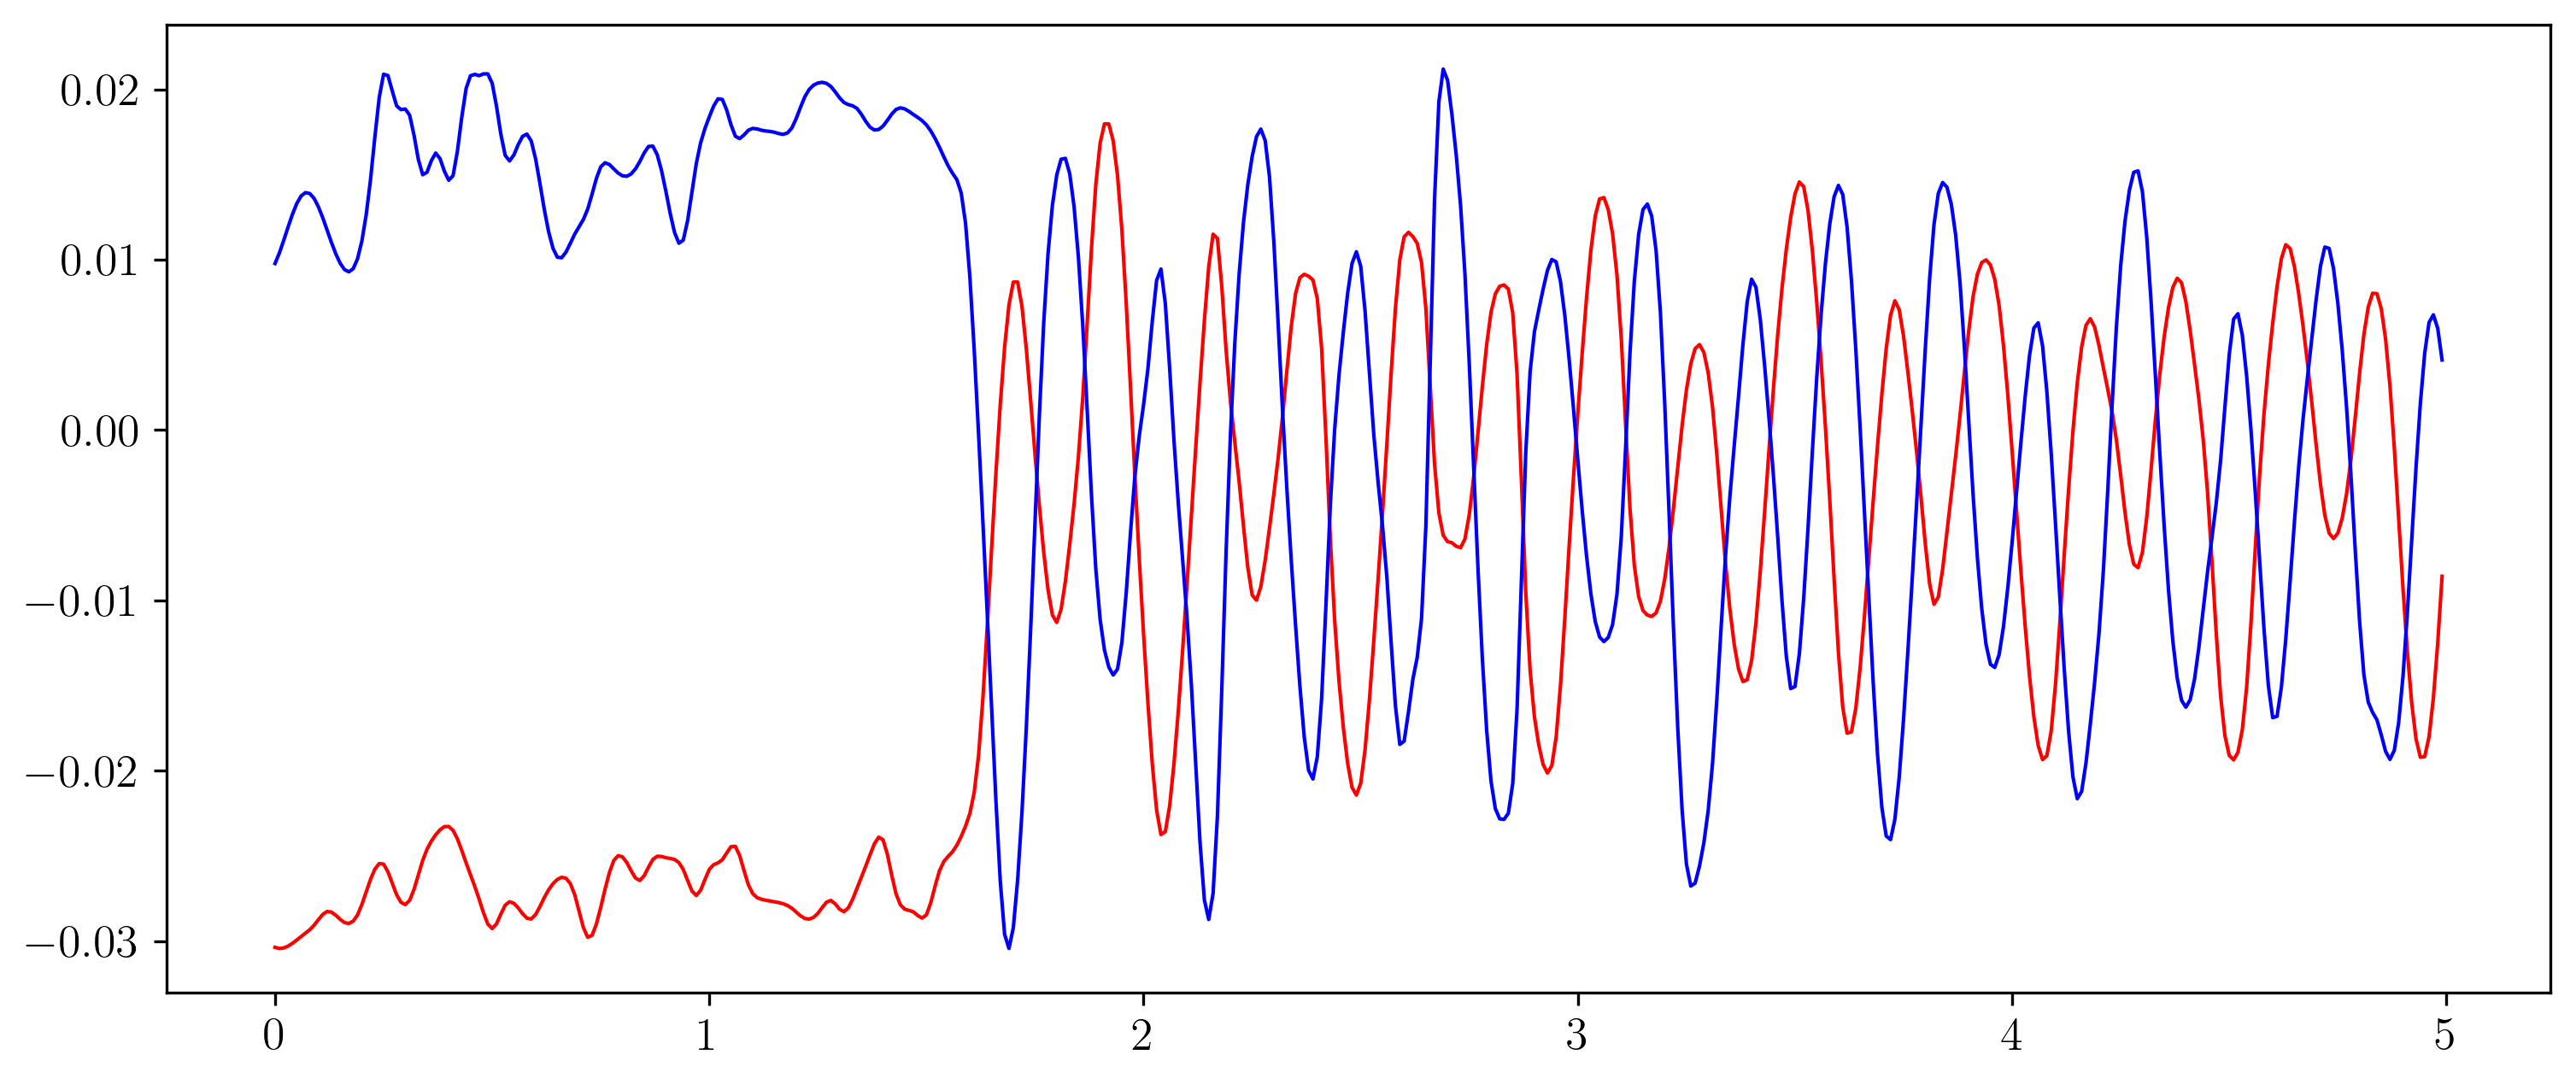

In [76]:
t = np.arange(0,5,0.01)
plt.plot(t,x1_spline(t),'-',color='red')
plt.plot(t,x2_spline(t),'-',color='blue')
plt.show()

# Plot data near start time

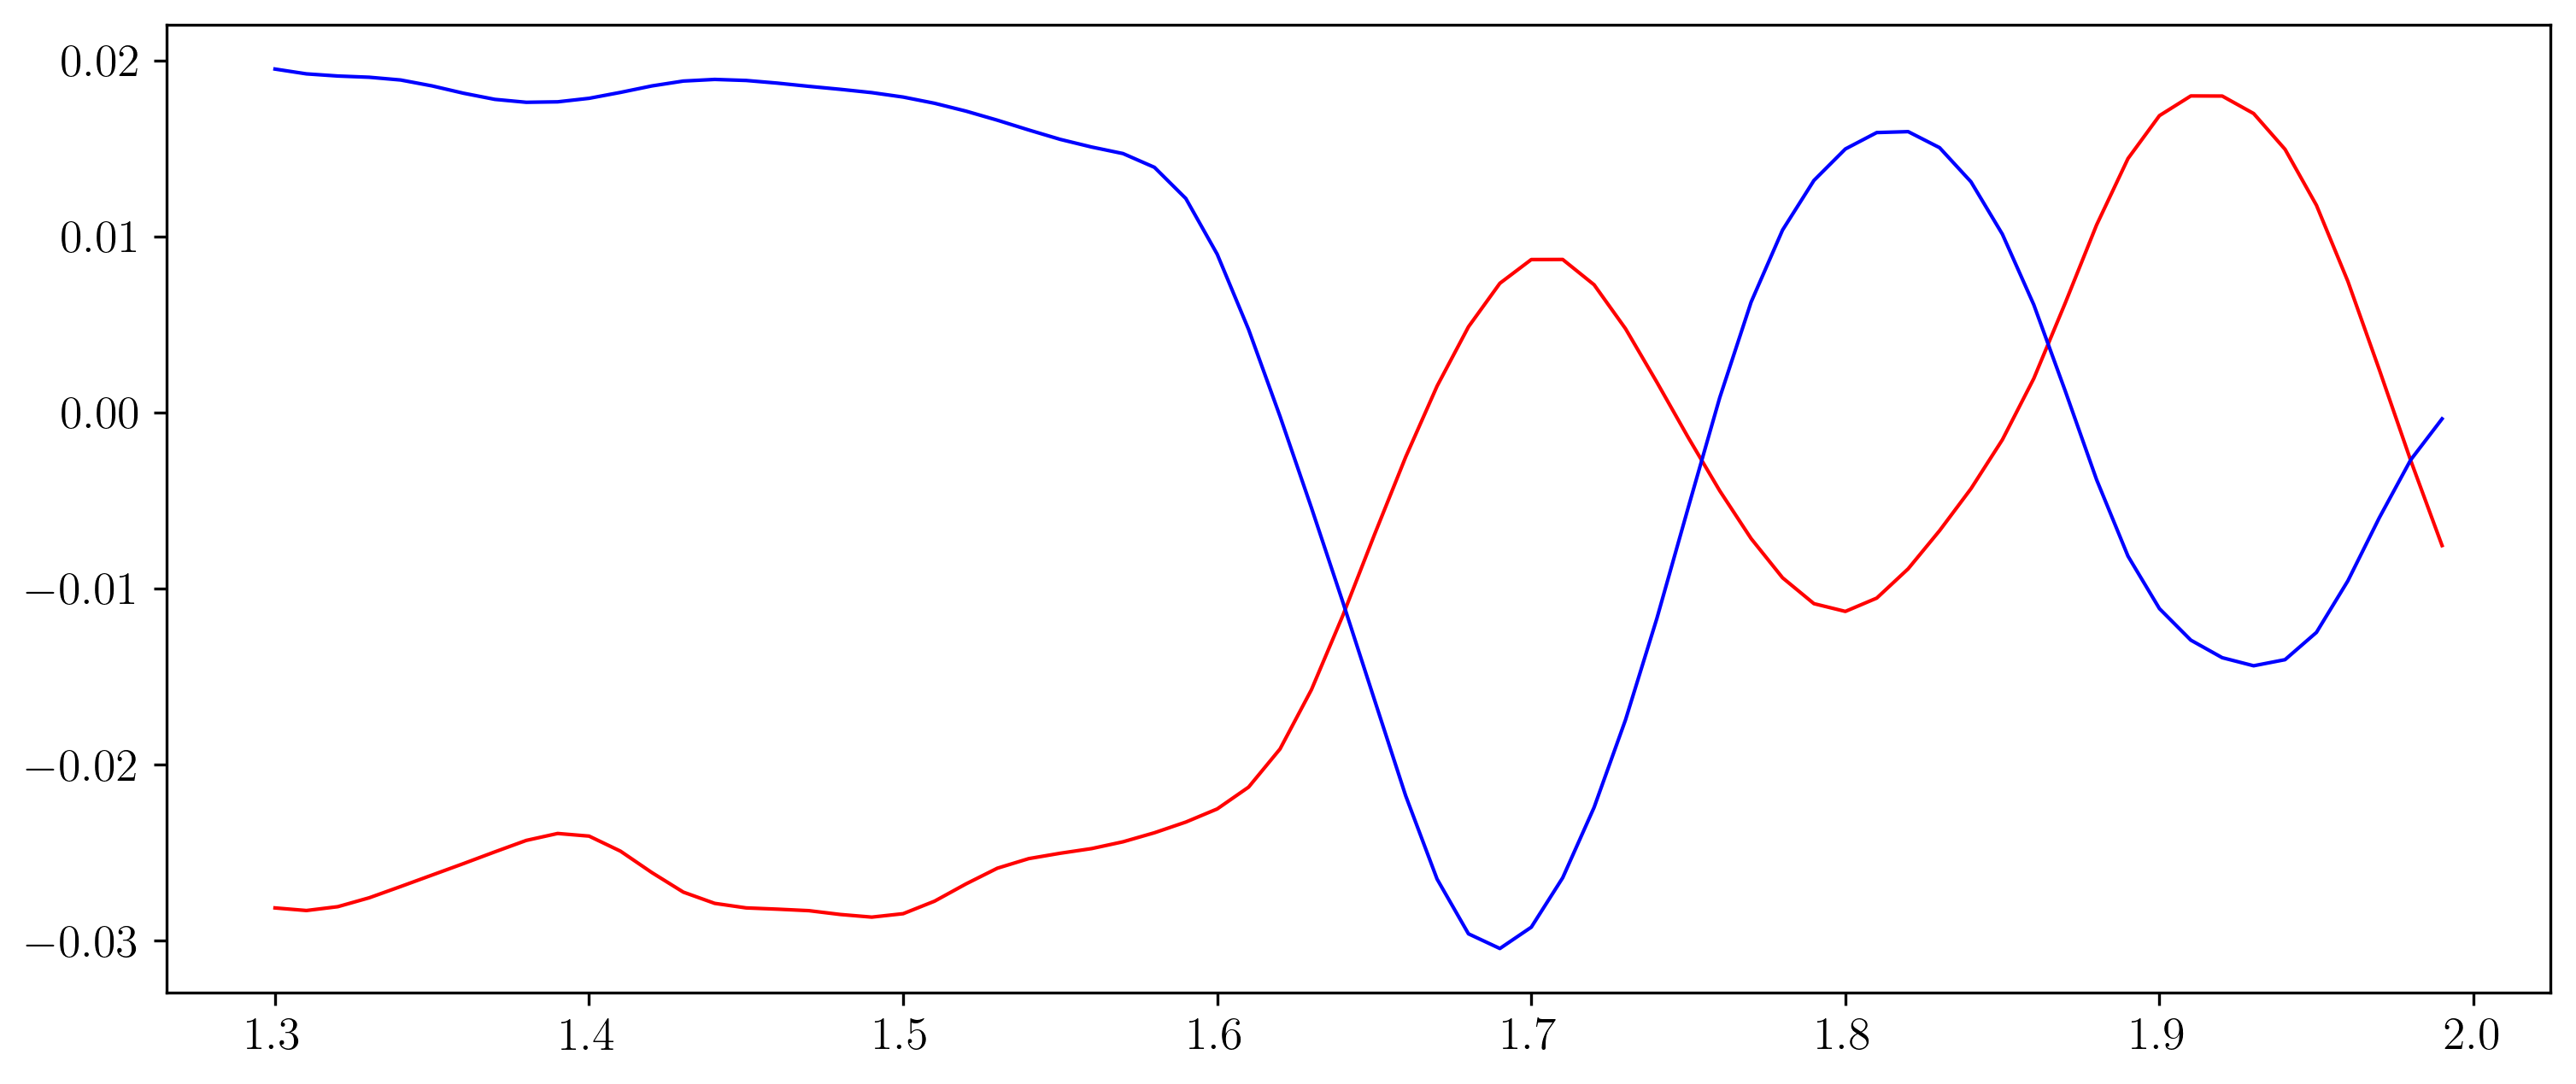

In [77]:
t_min = 1.3
t_max = 2.0
t = np.arange(t_min,t_max,0.01)
plt.plot(t,x1_spline(t),'-',color='red')
plt.plot(t,x2_spline(t),'-',color='blue')
plt.show()

choose $t_0$

In [78]:
t0 = 1.6

t0_index = np.argmax(time_sec > t0)

time_sec = time_sec[t0_index:]
x1_laser = x1_laser[t0_index:]
x2_laser = x2_laser[t0_index:]
x1_sound = x1_sound[t0_index:]
x2_sound = x2_sound[t0_index:]

# 時間平移，第一項為 0 
time_sec = time_sec - time_sec[0]

# 數據平滑
win_size = 5
x1 = savgol_filter(x1_sound, win_size, 3)
x2 = savgol_filter(x2_sound, win_size, 3)

# 數據差值
x1_spline = CubicSpline(time_sec, x1)
x2_spline = CubicSpline(time_sec, x2)

### plot shifted data

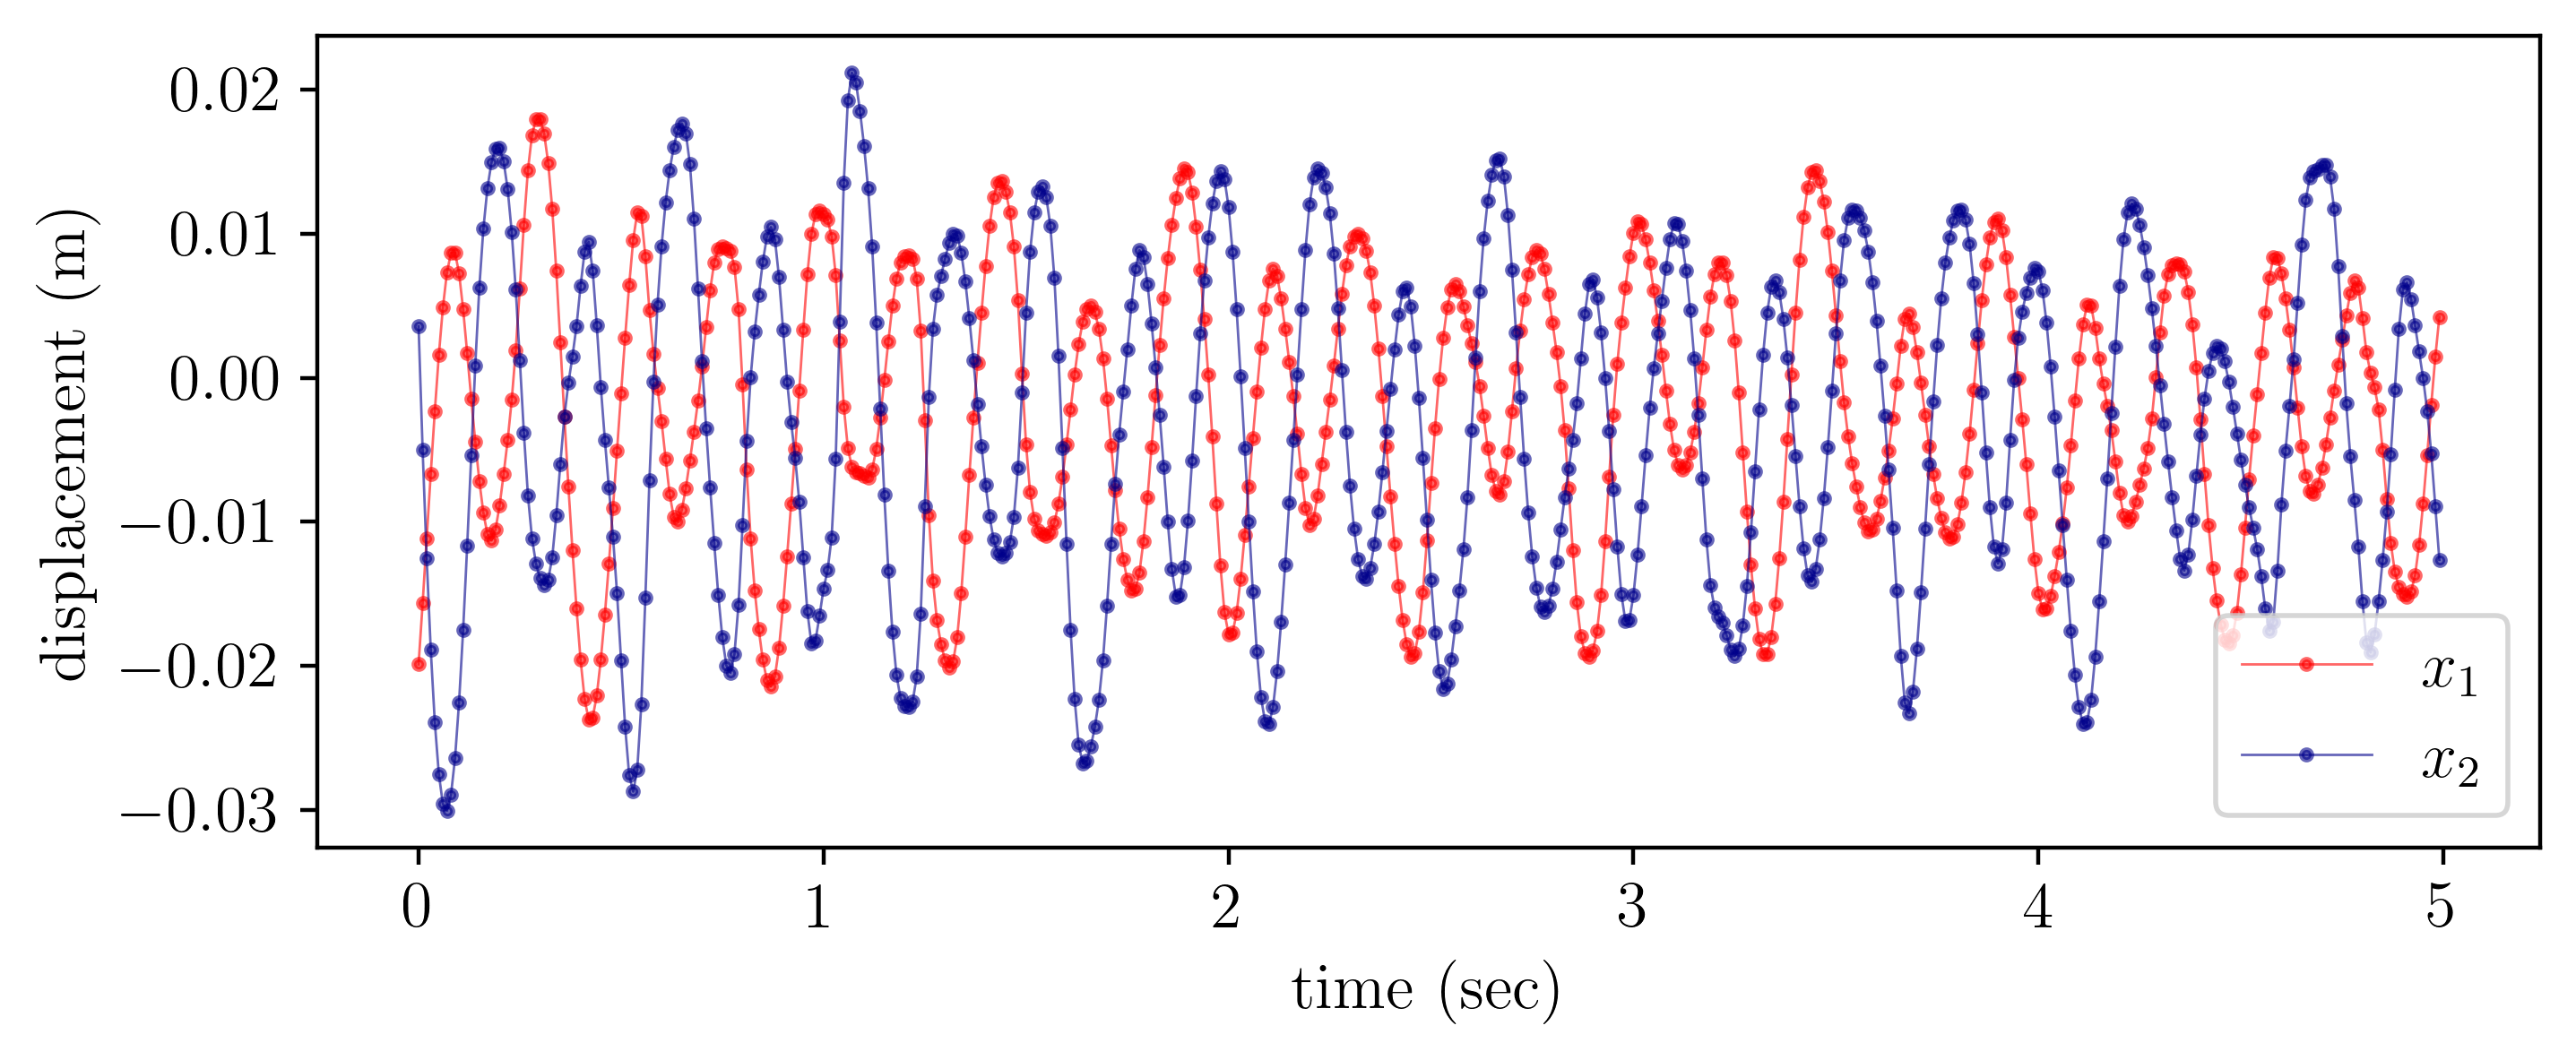

In [118]:
plt.figure(figsize=(8,3), dpi=400)

t = np.arange(0,5,0.01)
plt.plot(t,x1_spline(t),'-o', color='red',alpha=0.6,label="$x_1$",markersize=2,linewidth=0.5)
plt.plot(t,x2_spline(t),'-o',color='darkblue',alpha=0.6,label="$x_2$",markersize=2,linewidth=0.5)
plt.ylabel("displacement (m)")
plt.xlabel("time (sec)")
plt.legend()
plt.show()

### MCMC

In [106]:
x1_i = x1_spline(0)
x2_i = x2_spline(0)
m1 = 0.7216
m2 = 0.6950

def Coupled_Oscillator(t,k1,k2,k3, x1_i=x1_i, x2_i=x2_i, m1=m1, m2=m2):
    # Model
    trF  = -(m2*k1 + (m1+m2)*k2 + m1*k3)/(m1*m2) # Trace of Matrix
    detF =  (k1*k2 + k2*k3 + k3*k1)/(m1*m2)      # Determinant of Matrix
    lda1 =  (trF + sqrt(trF*trF-4*detF))/2       # 1st Eigen vlaue
    lda2 =  (trF - sqrt(trF*trF-4*detF))/2       # 2nd Eigen vlaue
    omega1 = sqrt(-lda1)                         # 1st Eigen frequence
    omega2 = sqrt(-lda2)                         # 2nd Eigen frequence)
    mu1 = array([[m2*lda1+(k2+k3)], [k2]])       # 1st Eigen vector
    mu2 = array([[m2*lda2+(k2+k3)], [k2]])       # 2nd Eigen vector
    M = np.hstack([mu1,mu2])                     # Matrix of Eigen vectors
    invM = inv(M)                                # inverse of Matrix
    C = invM@array([[x1_i],[x2_i]])              # coefficeints Matrix
    C1 = C[0][0]                                 # 1st coefficeint
    C2 = C[1][0]                                 # 2nd coefficeint
    psi = C1*cos(omega1*t)*mu1 + C2*cos(omega2*t)*mu2 # General Solution
    return psi[0],psi[1]

# ------------------------------------------------------------------------
def chi_square(t,paras):
    x1_theo ,x2_theo = Coupled_Oscillator(t,paras[0],paras[1],paras[2], x1_i=x1_i, x2_i=x2_i, m1=m1, m2=m2)
    x1_data = x1_spline(t)
    x2_data = x2_spline(t)
    chi1 = np.abs(np.sum((x1_data - x1_theo)**2 / (x1_theo+1e-16)))
    chi2 = np.abs(np.sum((x2_data - x2_theo)**2 / (x2_theo+1e-16)))
    return chi1,chi2

t = np.arange(0, 5, 0.01)

N = 10000
n = 3
delta = 1.0
Paras = np.zeros([N, n])
paras = np.array([200.0, 200.0, 200.0]) * 0.98 # (gf/cm -> N/m)
for i in range(N):
    paras_ = paras + delta * (2.0*random(n)-1.0)
#     while(np.sum(paras_<0)): paras_ = paras + delta * (2.0*random(n)-1.0)
    chi1, chi2= chi_square(t, paras)
    chi1_, chi2_ = chi_square(t, paras_)
    
    if((chi1_ <= chi1 and chi2_ <= chi2) or (random()  < (chi1*chi2)/(chi1_*chi2_))) :
        paras = paras_*1.0
    Paras[i] = paras

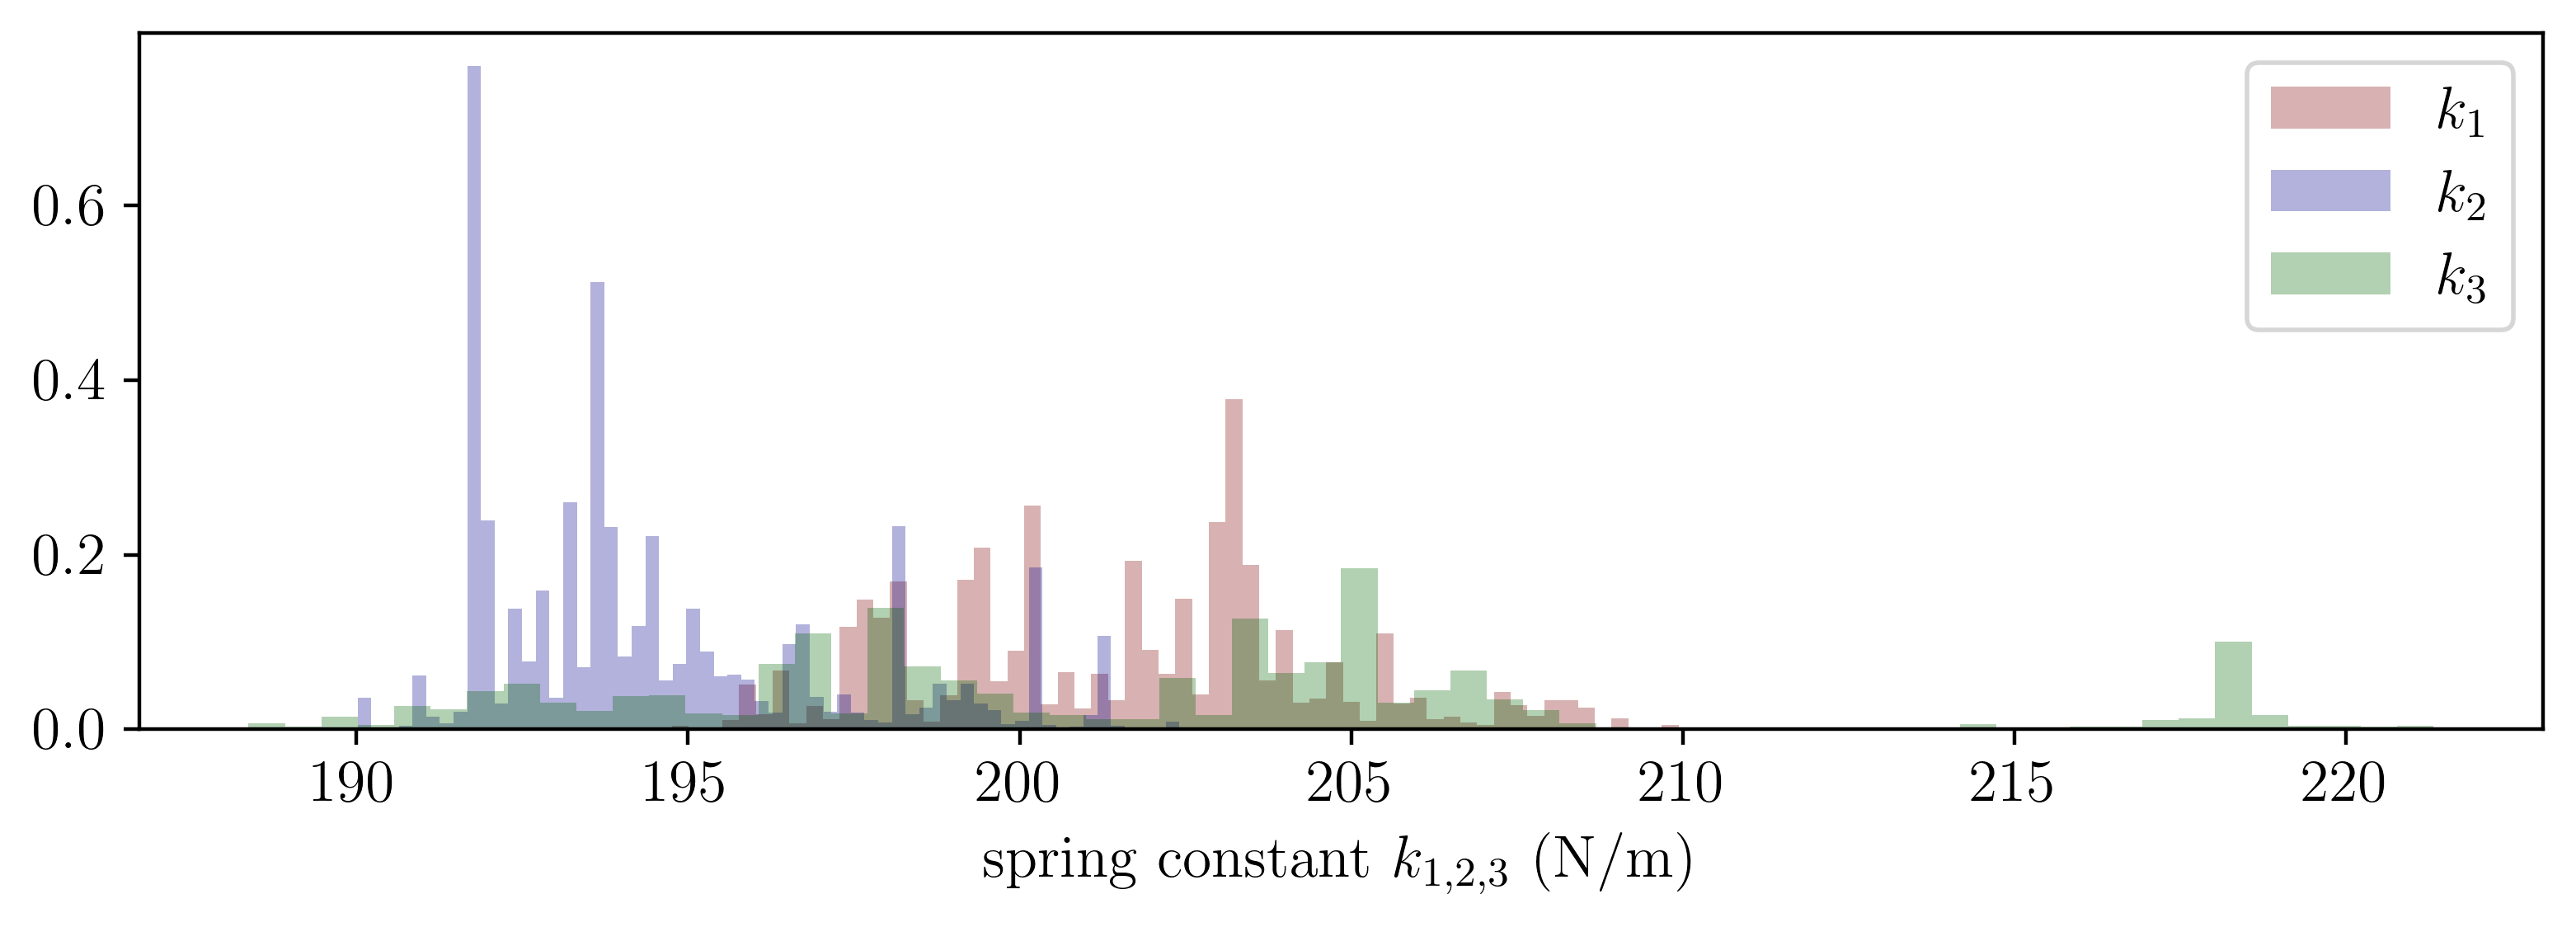

203.10454446445073 191.67008467554575 204.84785172982413


In [108]:
bins = 60

fig = plt.figure(figsize=(8,3), dpi=400)

P1, k1_hist, _ = plt.hist(Paras[:,0], bins=bins, color='maroon', density=True,alpha=0.3,label="$k_1$")
P2, k2_hist, _ = plt.hist(Paras[:,1], bins=bins, color='darkblue', density=True,alpha=0.3,label="$k_2$")
P3, k3_hist, _ = plt.hist(Paras[:,2], bins=bins, color='darkgreen', density=True,alpha=0.3,label="$k_3$")

plt.xlabel("spring constant $k_{1,2,3}$ (N/m)")

plt.tight_layout()
plt.legend()
plt.show()


k1_max = k1_hist[np.where(P1 == P1.max())][0]
k2_max = k2_hist[np.where(P2 == P2.max())][0]
k3_max = k3_hist[np.where(P3 == P3.max())][0]
print(k1_max,k2_max,k3_max)

In [83]:
fig.savefig(f"./result/{k1_max},{k2_max},{k3_max}.pdf")

## Compare

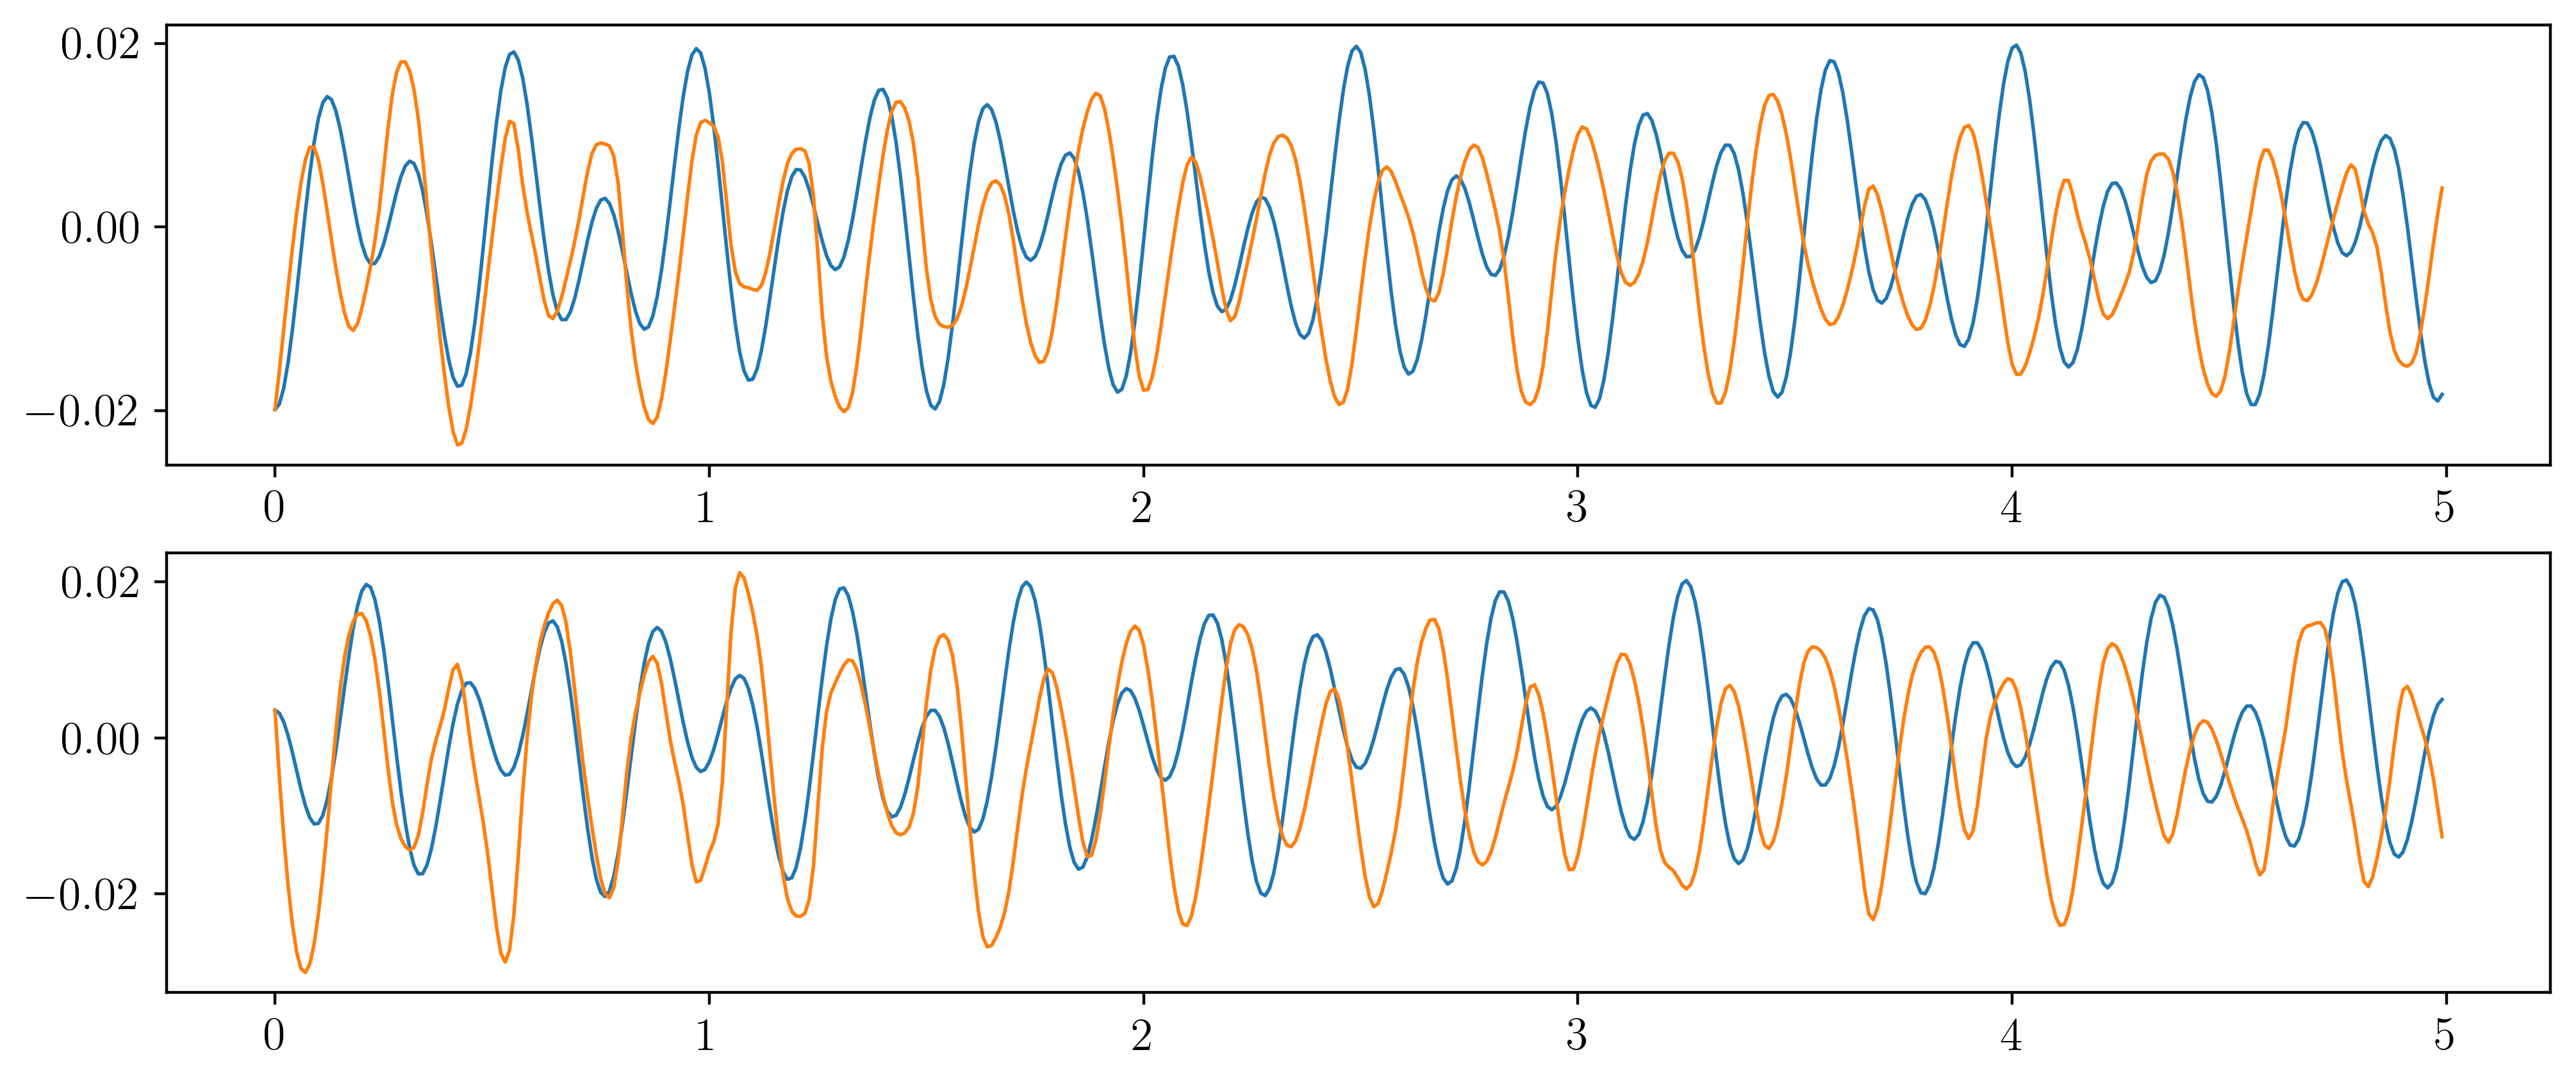

In [101]:
x1,x2 = Coupled_Oscillator(t, k1_max, k2_max, k3_max, x1_i=x1_i, x2_i=x2_i, m1=m1, m2=m2)

plt.figure(figsize=(12,5),dpi=400)
plt.subplot(2,1,1)
plt.plot(t,x1)
plt.plot(t,x1_spline(t))

plt.subplot(2,1,2)
plt.plot(t,x2)
plt.plot(t,x2_spline(t))
plt.show()

# Run many time MCMC

In [25]:
def MCMC(m1,m2,N=10000):
    x1_i = x1_spline(0)
    x2_i = x2_spline(0)
    m1 = 0.7216
    m2 = 0.6950

    def Coupled_Oscillator(t,k1,k2,k3, x1_i=x1_i, x2_i=x2_i, m1=m1, m2=m2):
        # Model
        trF  = -(m2*k1 + (m1+m2)*k2 + m1*k3)/(m1*m2) # Trace of Matrix
        detF =  (k1*k2 + k2*k3 + k3*k1)/(m1*m2)      # Determinant of Matrix
        lda1 =  (trF + sqrt(trF*trF-4*detF))/2       # 1st Eigen vlaue
        lda2 =  (trF - sqrt(trF*trF-4*detF))/2       # 2nd Eigen vlaue
        omega1 = sqrt(-lda1)                         # 1st Eigen frequence
        omega2 = sqrt(-lda2)                         # 2nd Eigen frequence)
        mu1 = array([[m2*lda1+(k2+k3)], [k2]])       # 1st Eigen vector
        mu2 = array([[m2*lda2+(k2+k3)], [k2]])       # 2nd Eigen vector
        M = np.hstack([mu1,mu2])                     # Matrix of Eigen vectors
        invM = inv(M)                                # inverse of Matrix
        C = invM@array([[x1_i],[x2_i]])              # coefficeints Matrix
        C1 = C[0][0]                                 # 1st coefficeint
        C2 = C[1][0]                                 # 2nd coefficeint
        psi = C1*cos(omega1*t)*mu1 + C2*cos(omega2*t)*mu2 # General Solution
        return psi[0],psi[1]

    # ------------------------------------------------------------------------
    def chi_square(t,paras):
        x1_theo ,x2_theo = Coupled_Oscillator(t,paras[0],paras[1],paras[2], x1_i=x1_i, x2_i=x2_i, m1=m1, m2=m2)
        x1_data = x1_spline(t)
        x2_data = x2_spline(t)
        chi1 = np.abs(np.sum((x1_data - x1_theo)**2 / (x1_theo+1e-16)))
        chi2 = np.abs(np.sum((x2_data - x2_theo)**2 / (x2_theo+1e-16)))
        return chi1,chi2

    t = np.arange(0, 5, 0.01)

    n = 3
    delta = 2.0
    Paras = np.zeros([N, n])
    paras = np.array([200.0, 200.0, 200.0]) * 0.98 # (gf/cm -> N/m)
    for i in range(N):
        paras_ = paras + delta * (2.0*random(n)-1.0)
    #     while(np.sum(paras_<0)): paras_ = paras + delta * (2.0*random(n)-1.0)
        chi1, chi2= chi_square(t, paras)
        chi1_, chi2_ = chi_square(t, paras_)

        if((chi1_ <= chi1 and chi2_ <= chi2) or (random()  < (chi1*chi2)/(chi1_*chi2_))) :
            paras = paras_*1.0
        Paras[i] = paras
    bins = 50

    fig = plt.figure(figsize=(12,5), dpi=200)

    plt.subplot(3,1,1)
    P1, k1_hist, _ = plt.hist(Paras[:,0], bins=bins, color='red', density=True)

    plt.subplot(3,1,2)
    P2, k2_hist, _ = plt.hist(Paras[:,1], bins=bins, color='blue', density=True)

    plt.subplot(3,1,3)
    P3, k3_hist, _ = plt.hist(Paras[:,2], bins=bins, color='green', density=True)
    plt.tight_layout()
    plt.show()


    k1_max = k1_hist[np.where(P1 == P1.max())][0]
    k2_max = k2_hist[np.where(P2 == P2.max())][0]
    k3_max = k3_hist[np.where(P3 == P3.max())][0]
    print(k1_max,k2_max,k3_max)

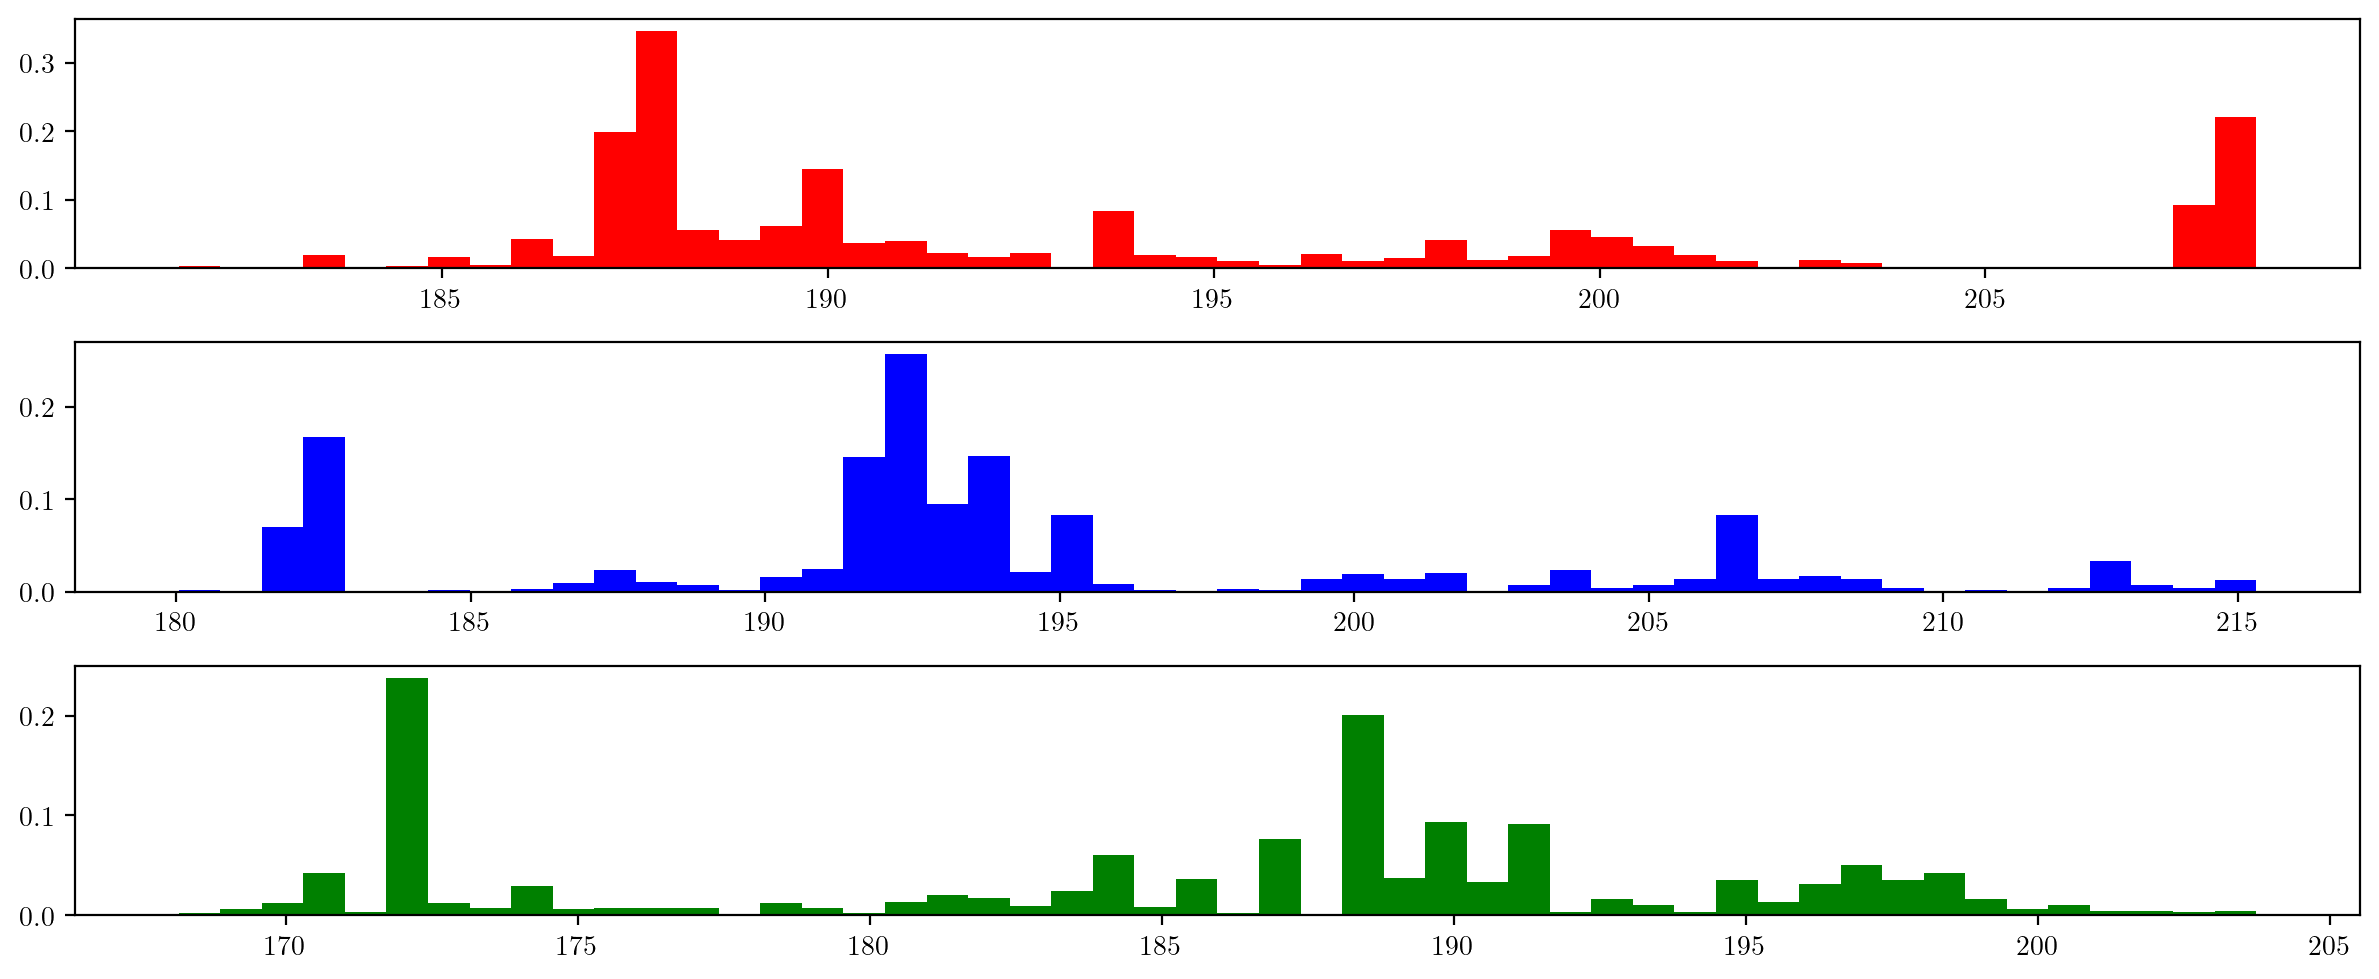

187.51036504473242 192.0315359620903 171.721664284569


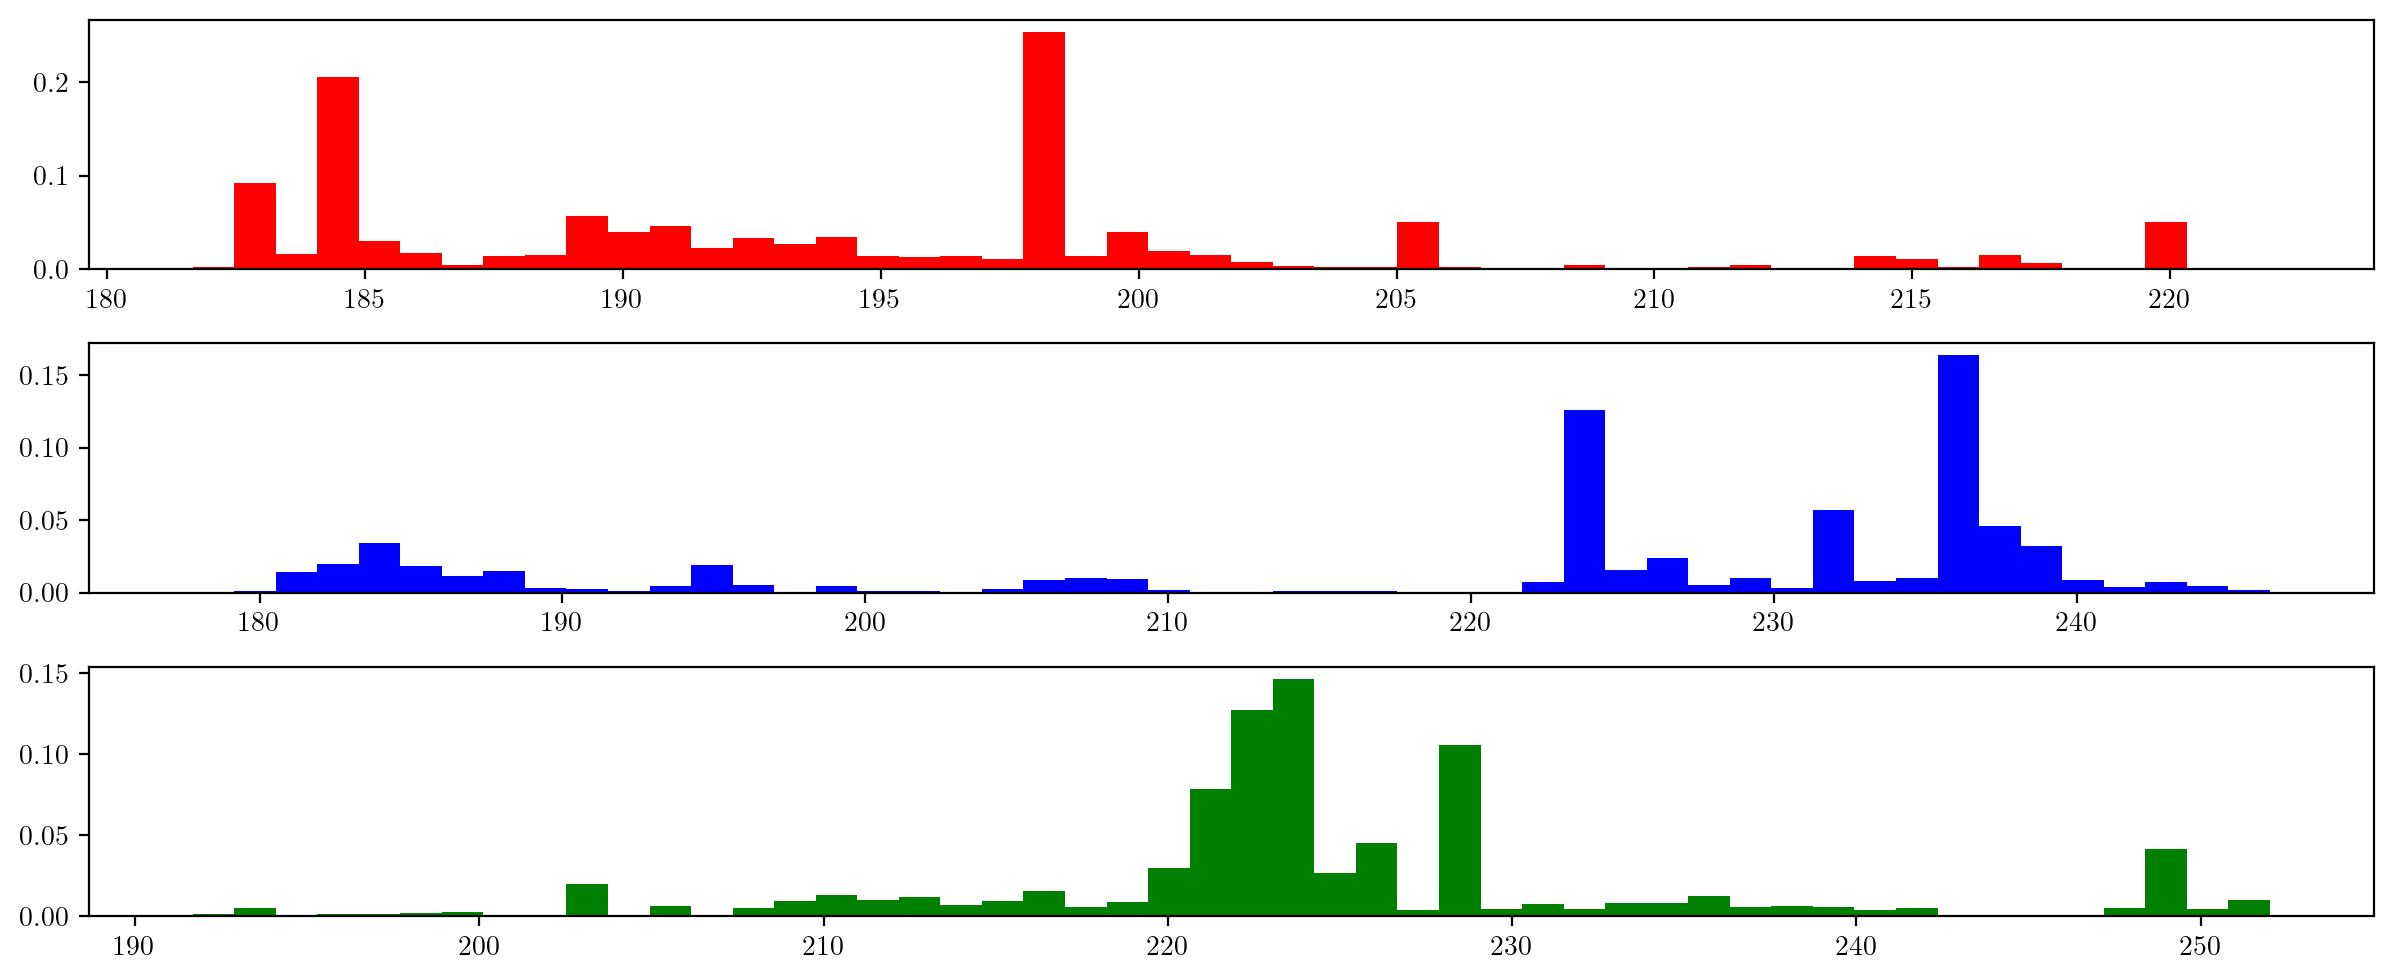

197.76572620748024 235.4113851090354 223.04634587264124


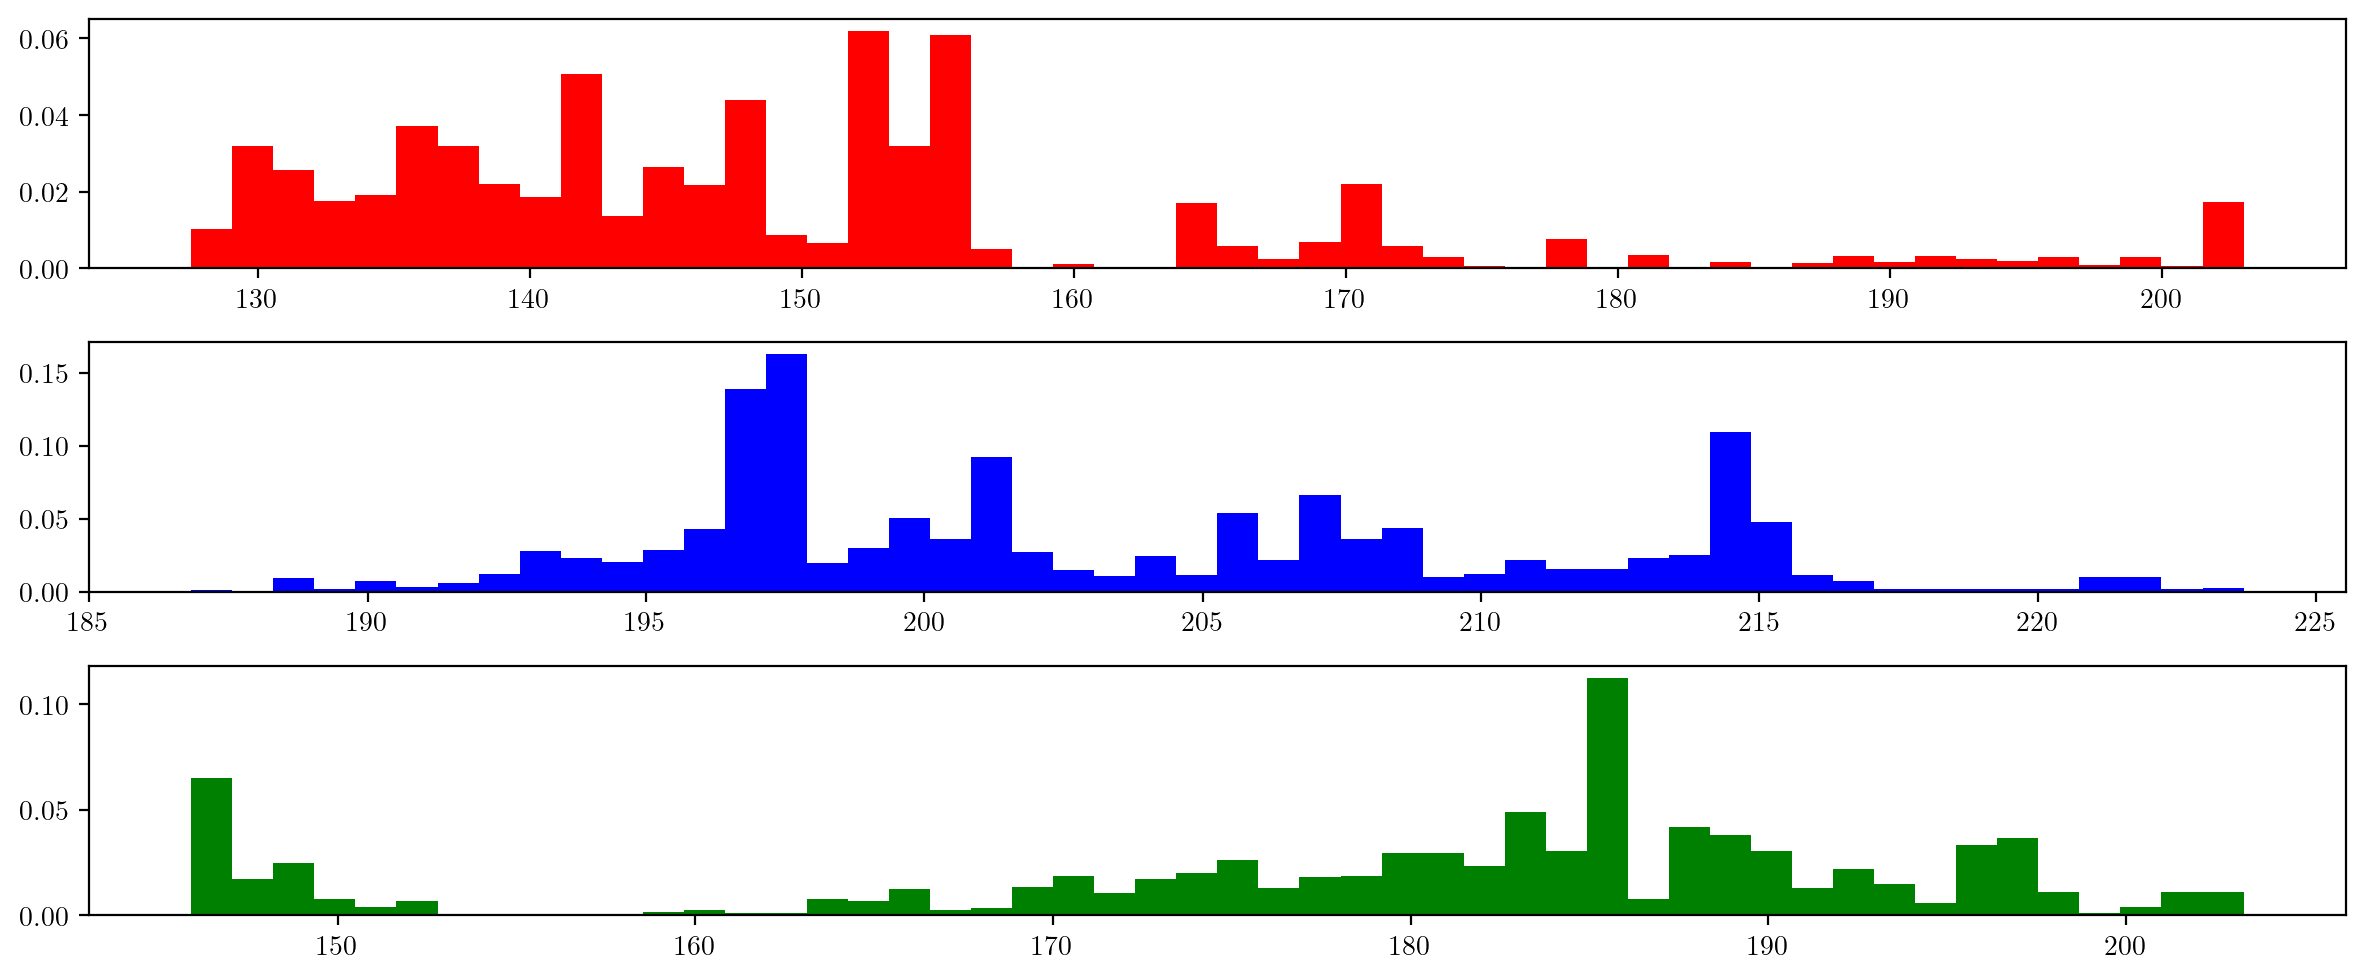

151.6975073152671 197.15440089008177 184.92420730230043


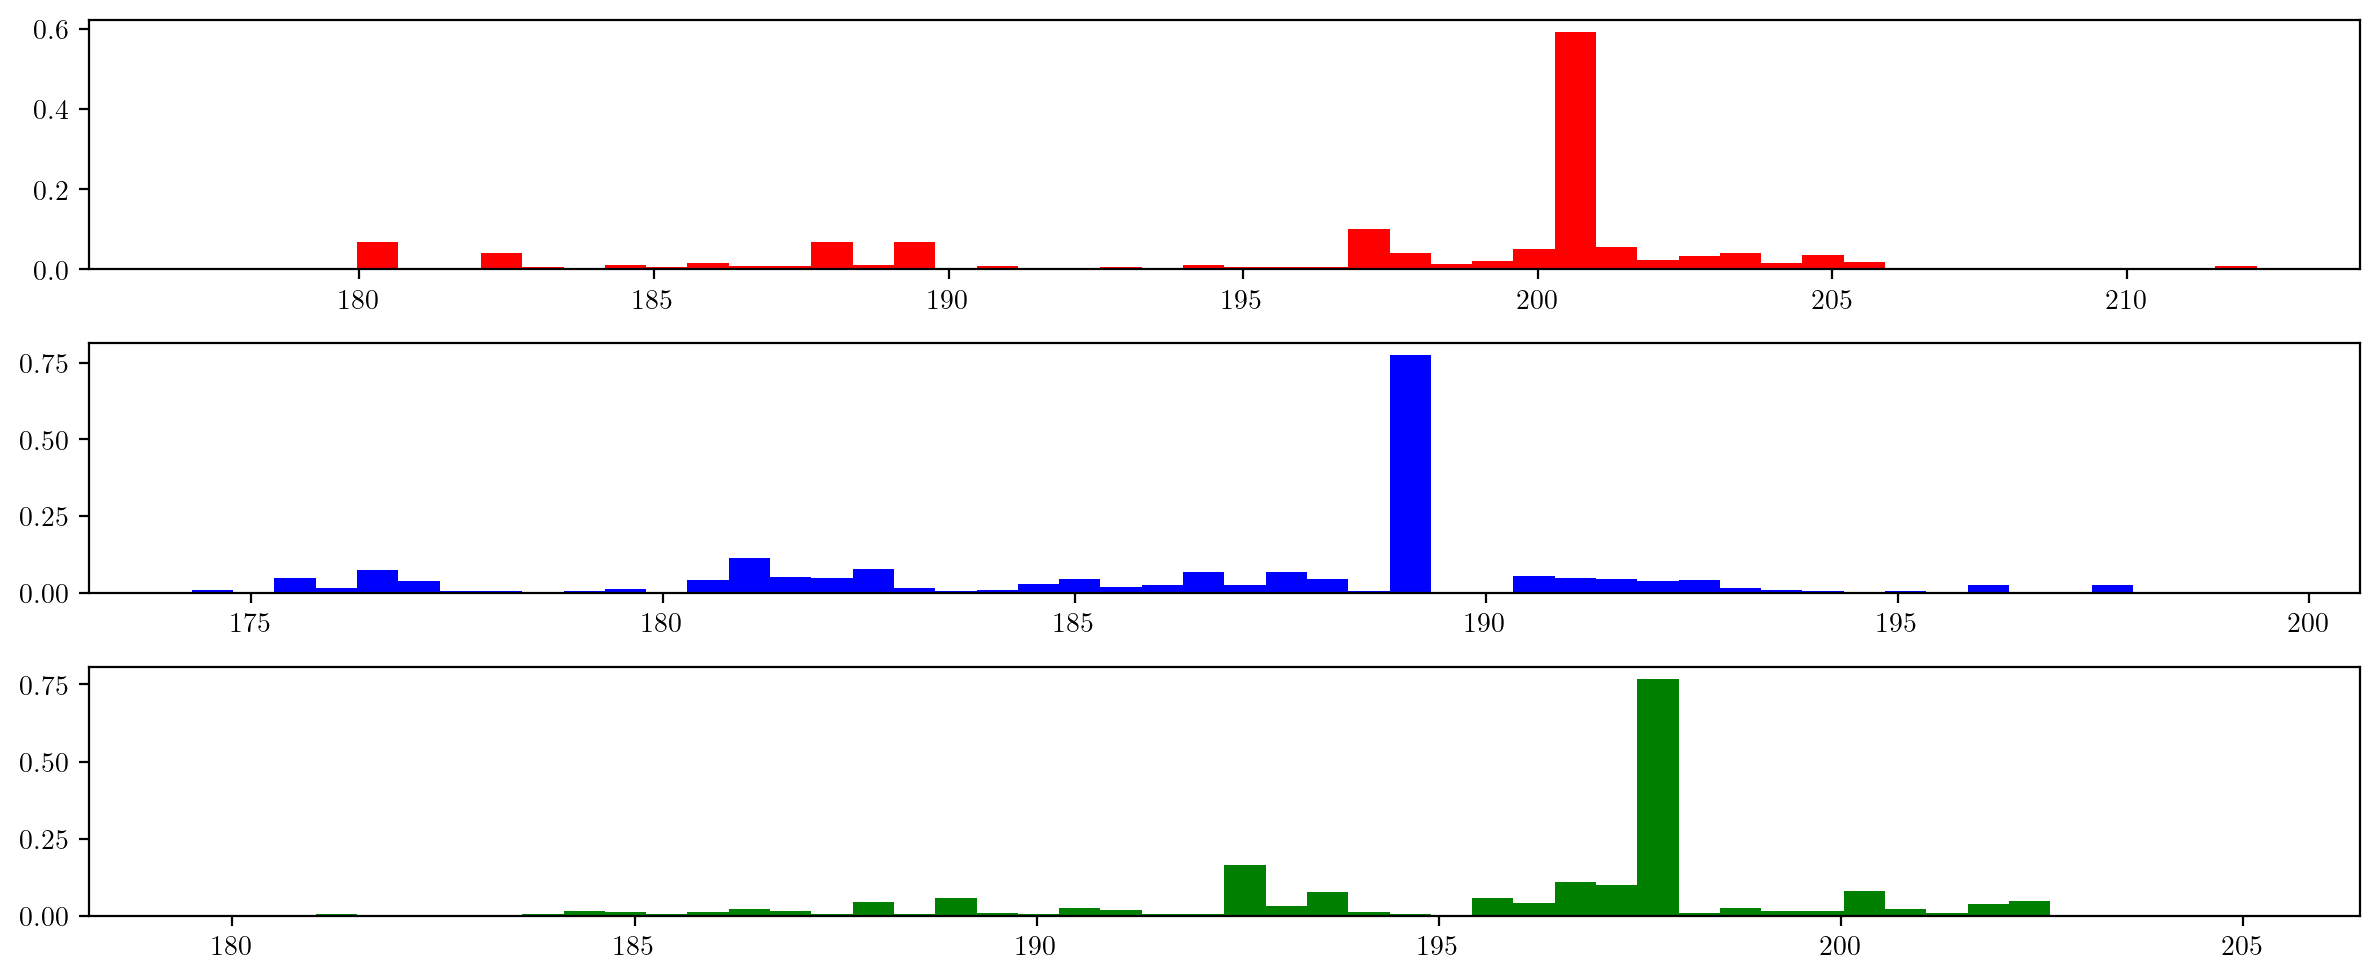

200.28667233673062 188.82685860731002 197.4677069746867


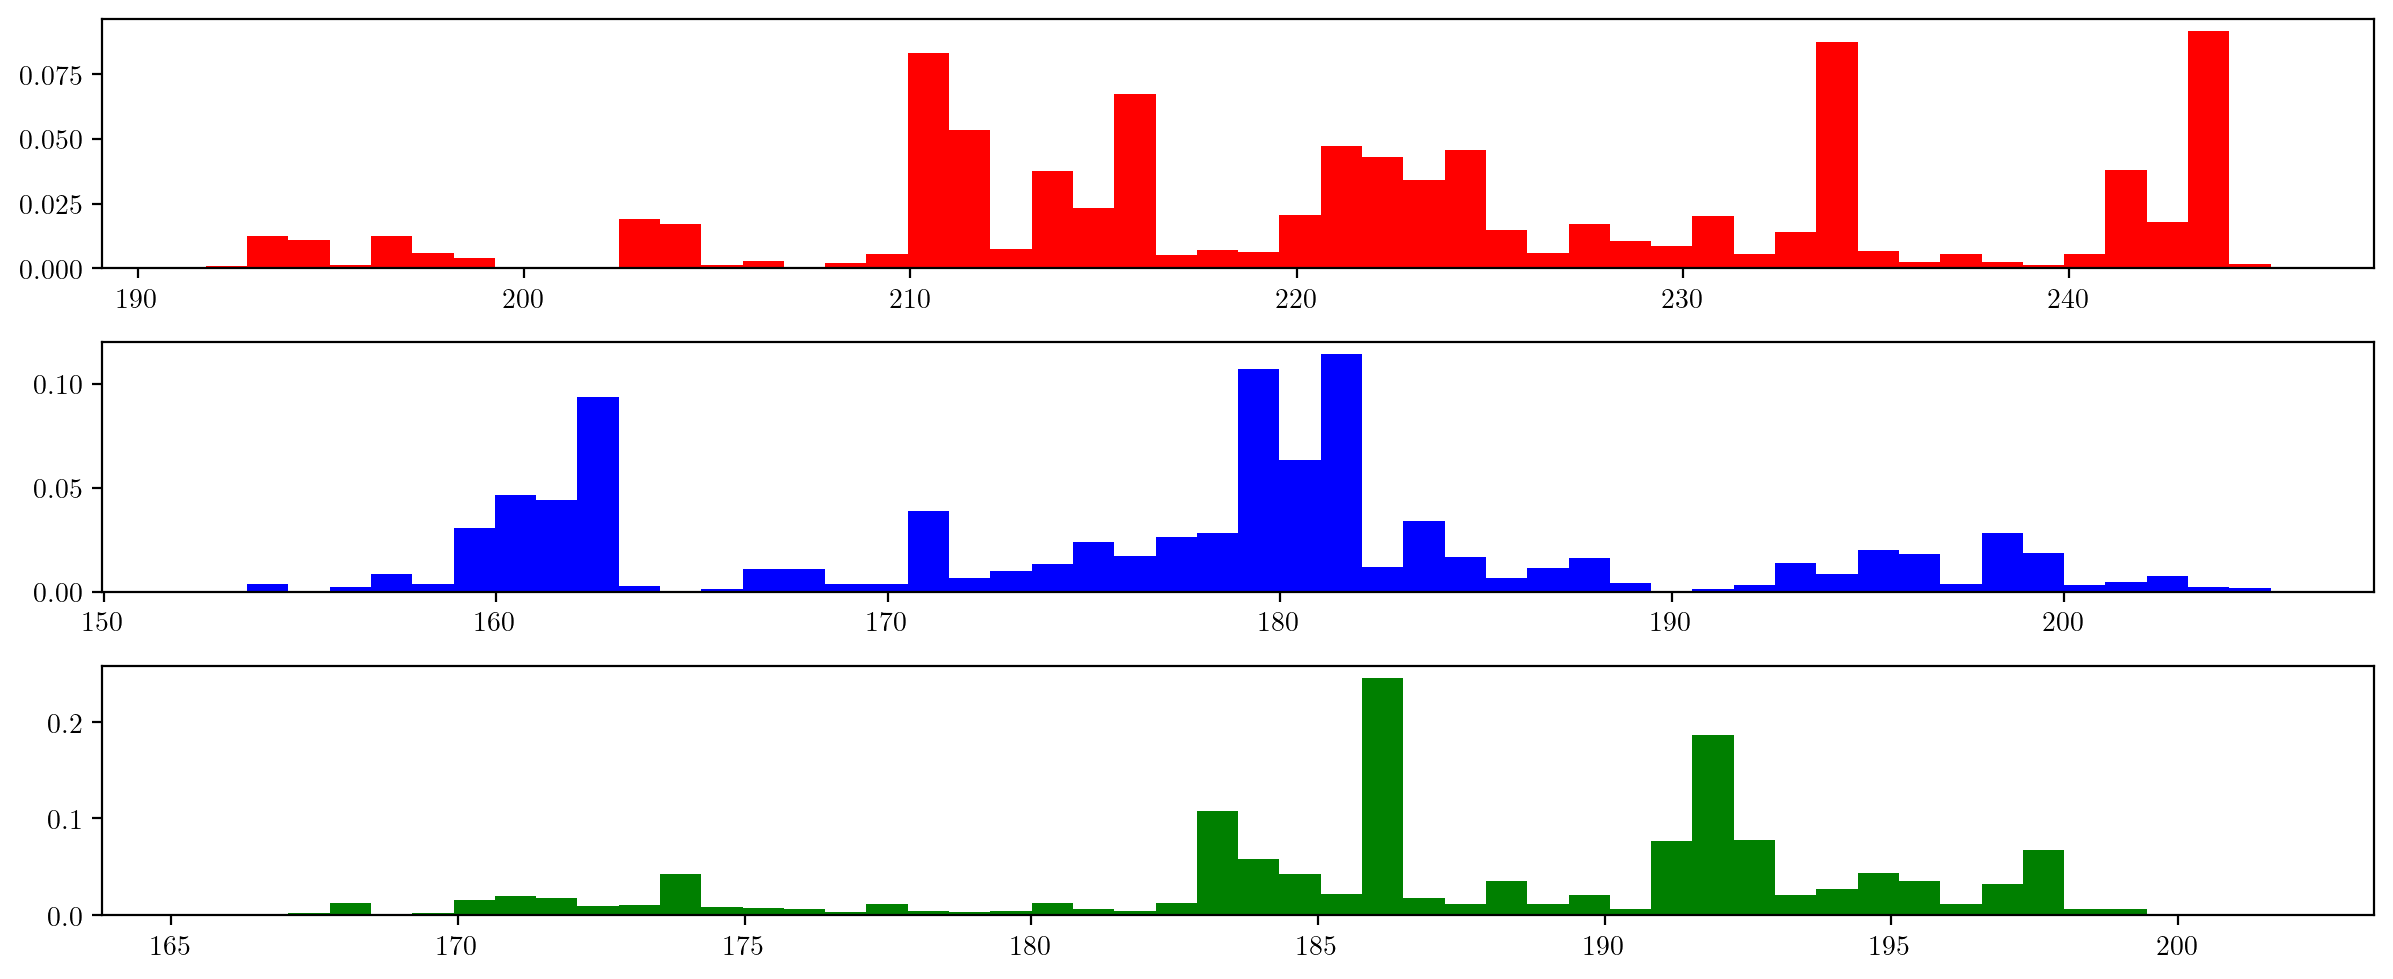

243.07708964519838 181.0429061046737 185.76990473701534


[None, None, None, None, None]

In [27]:
[MCMC(m1=0.7216,m2=0.6950) for i in range(5)]

In [85]:
def MCMC_paras(m1,m2,N=10000):
    x1_i = x1_spline(0)
    x2_i = x2_spline(0)
    m1 = 0.7216
    m2 = 0.6950

    def Coupled_Oscillator(t,k1,k2,k3, x1_i=x1_i, x2_i=x2_i, m1=m1, m2=m2):
        # Model
        trF  = -(m2*k1 + (m1+m2)*k2 + m1*k3)/(m1*m2) # Trace of Matrix
        detF =  (k1*k2 + k2*k3 + k3*k1)/(m1*m2)      # Determinant of Matrix
        lda1 =  (trF + sqrt(trF*trF-4*detF))/2       # 1st Eigen vlaue
        lda2 =  (trF - sqrt(trF*trF-4*detF))/2       # 2nd Eigen vlaue
        omega1 = sqrt(-lda1)                         # 1st Eigen frequence
        omega2 = sqrt(-lda2)                         # 2nd Eigen frequence)
        mu1 = array([[m2*lda1+(k2+k3)], [k2]])       # 1st Eigen vector
        mu2 = array([[m2*lda2+(k2+k3)], [k2]])       # 2nd Eigen vector
        M = np.hstack([mu1,mu2])                     # Matrix of Eigen vectors
        invM = inv(M)                                # inverse of Matrix
        C = invM@array([[x1_i],[x2_i]])              # coefficeints Matrix
        C1 = C[0][0]                                 # 1st coefficeint
        C2 = C[1][0]                                 # 2nd coefficeint
        psi = C1*cos(omega1*t)*mu1 + C2*cos(omega2*t)*mu2 # General Solution
        return psi[0],psi[1]

    # ------------------------------------------------------------------------
    def chi_square(t,paras):
        x1_theo ,x2_theo = Coupled_Oscillator(t,paras[0],paras[1],paras[2], x1_i=x1_i, x2_i=x2_i, m1=m1, m2=m2)
        x1_data = x1_spline(t)
        x2_data = x2_spline(t)
        chi1 = np.abs(np.sum((x1_data - x1_theo)**2 / (x1_theo+1e-16)))
        chi2 = np.abs(np.sum((x2_data - x2_theo)**2 / (x2_theo+1e-16)))
        return chi1,chi2

    t = np.arange(0, 5, 0.01)

    n = 3
    delta = 2.0
    Paras = np.zeros([N, n])
    paras = np.array([200.0, 200.0, 200.0]) * 0.98 # (gf/cm -> N/m)
    for i in range(N):
        paras_ = paras + delta * (2.0*random(n)-1.0)
    #     while(np.sum(paras_<0)): paras_ = paras + delta * (2.0*random(n)-1.0)
        chi1, chi2= chi_square(t, paras)
        chi1_, chi2_ = chi_square(t, paras_)

        if((chi1_ <= chi1 and chi2_ <= chi2) or (random()  < (chi1*chi2)/(chi1_*chi2_))) :
            paras = paras_*1.0
        Paras[i] = paras
    return Paras

In [86]:
Paras = MCMC_paras(m1=0.7216,m2=0.6950, N=10000)
for i in range(9):
    Paras = np.vstack([Paras, MCMC_paras(m1=0.7216,m2=0.6950, N=100000)])

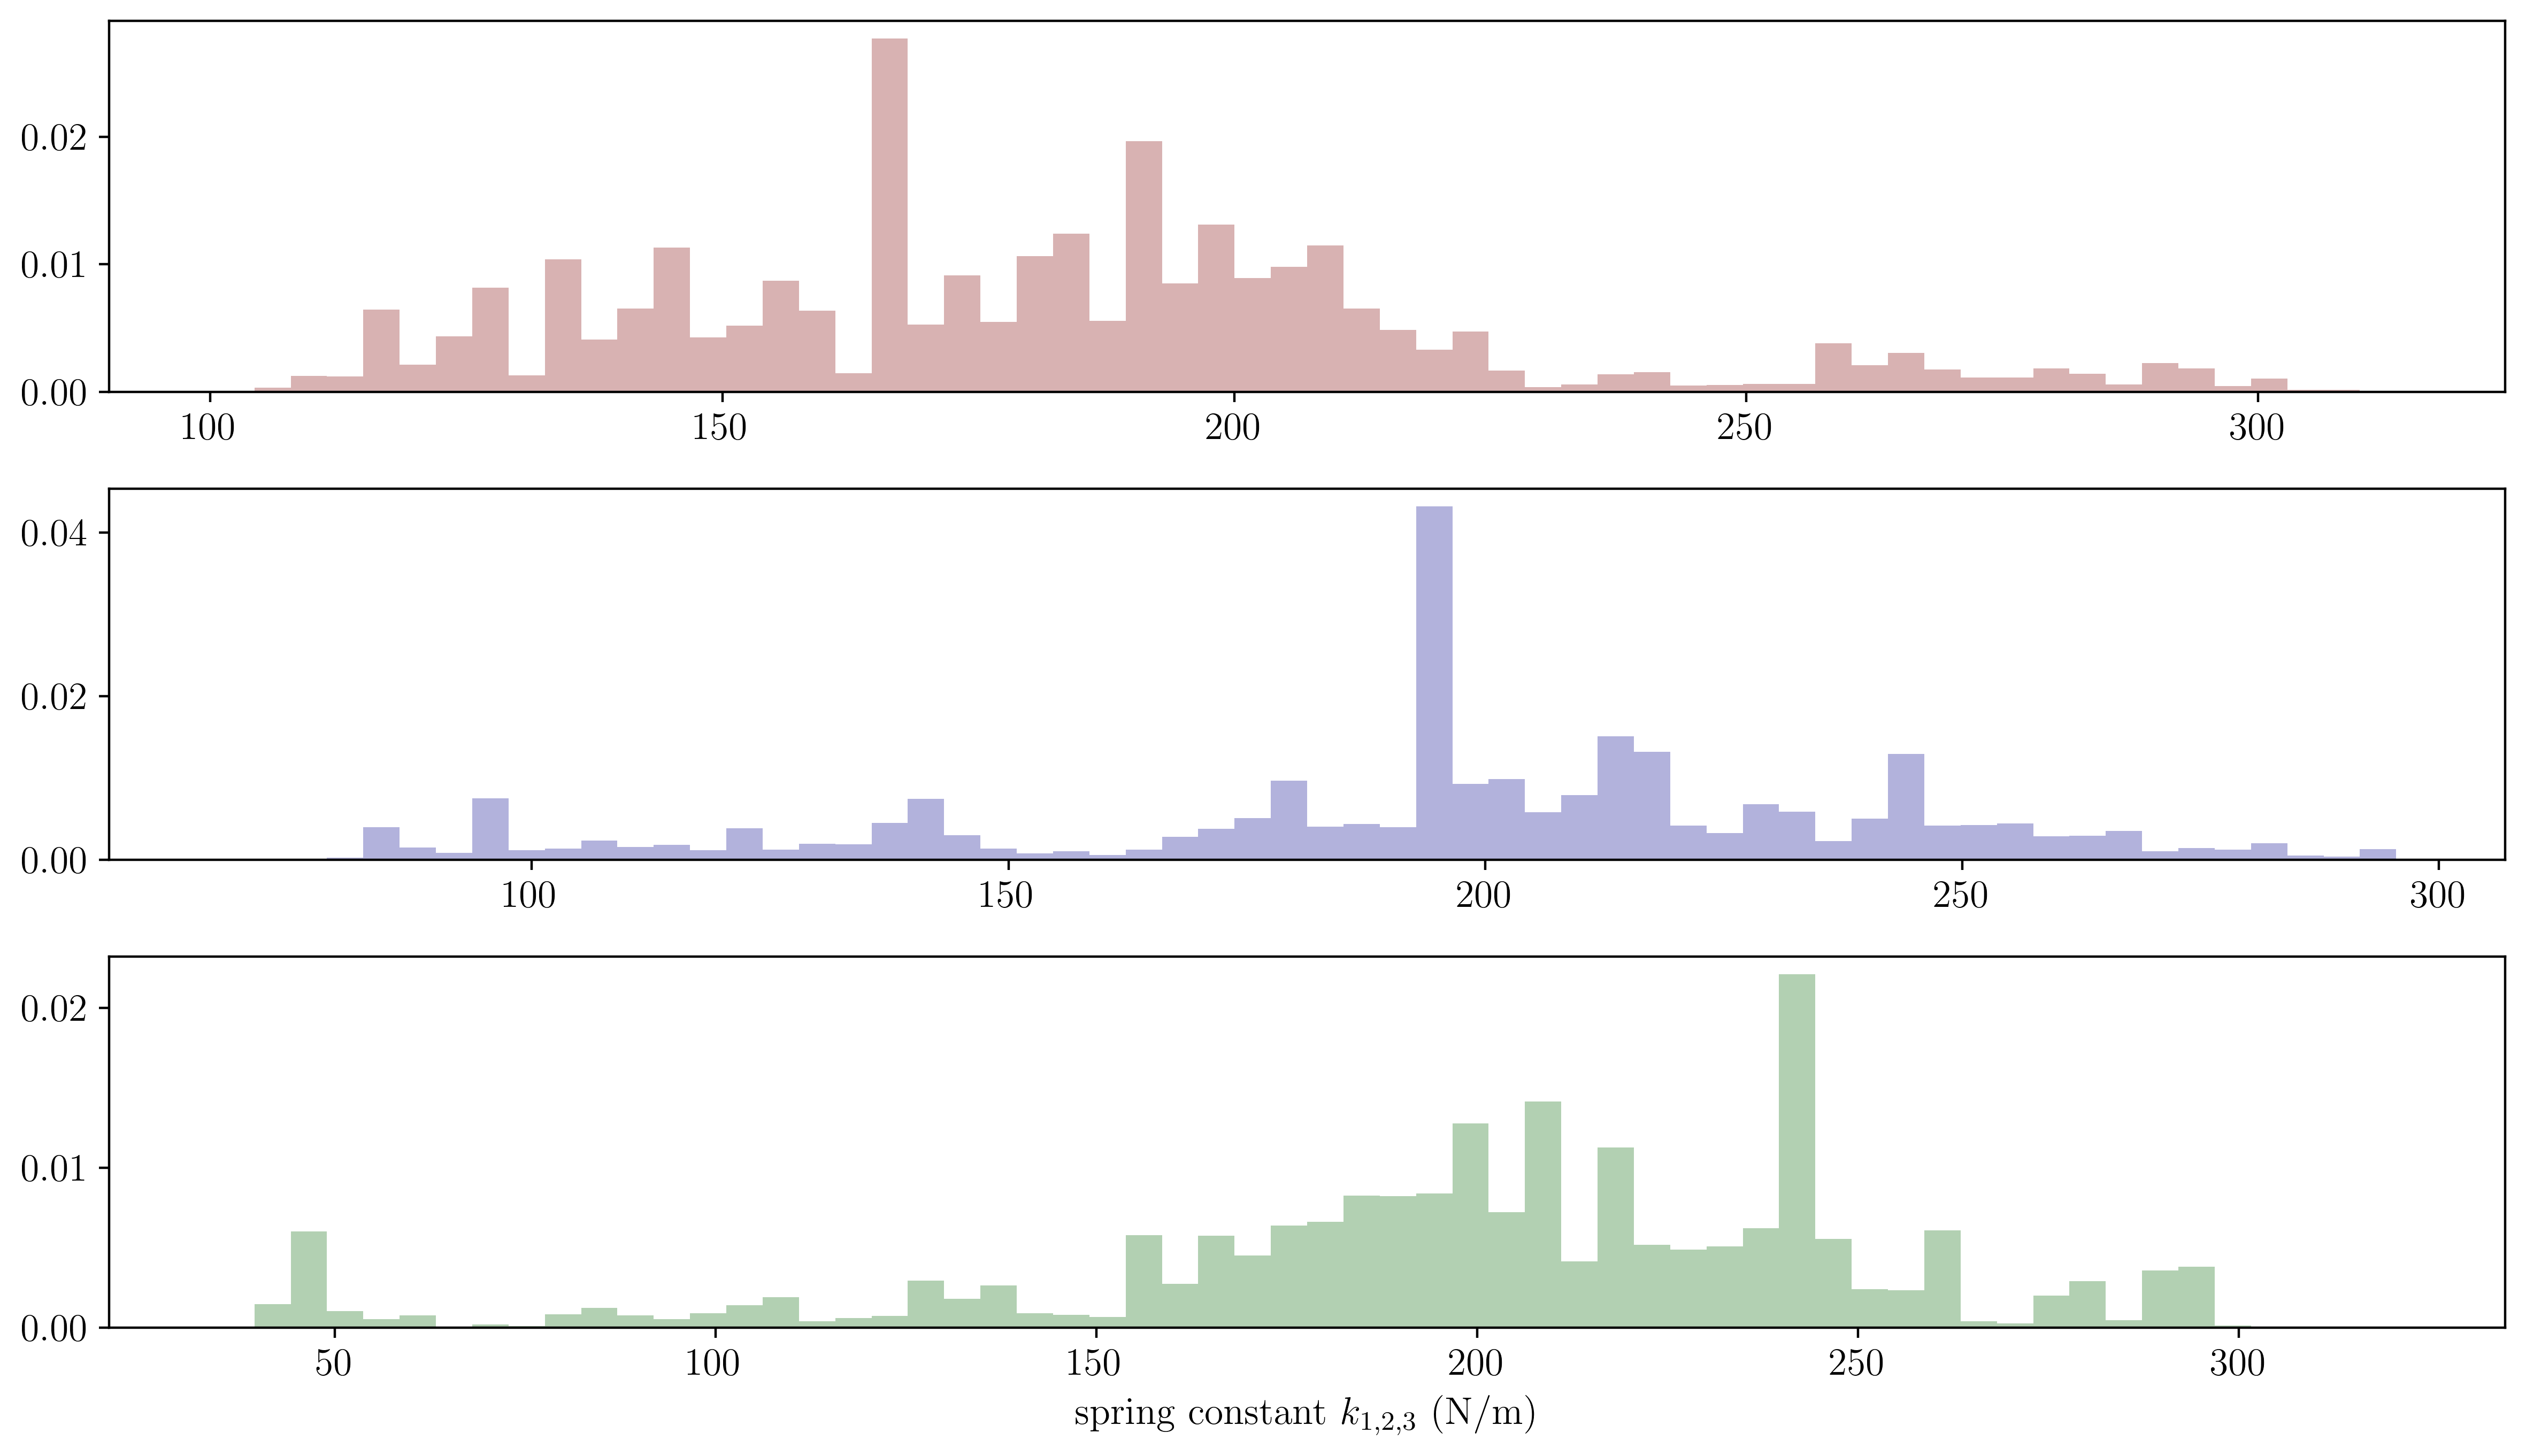

164.5723746134656 192.743985792317 239.6346682618747


In [87]:
bins = 60

fig = plt.figure(figsize=(12,7), dpi=400)

plt.subplot(3,1,1)
P1, k1_hist, _ = plt.hist(Paras[:,0], bins=bins, color='maroon', density=True,alpha=0.3)

plt.subplot(3,1,2)
P2, k2_hist, _ = plt.hist(Paras[:,1], bins=bins, color='darkblue', density=True,alpha=0.3)

plt.subplot(3,1,3)
P3, k3_hist, _ = plt.hist(Paras[:,2], bins=bins, color='darkgreen', density=True,alpha=0.3)

plt.xlabel("spring constant $k_{1,2,3}$ (N/m)")

plt.tight_layout()
plt.show()


k1_max = k1_hist[np.where(P1 == P1.max())][0]
k2_max = k2_hist[np.where(P2 == P2.max())][0]
k3_max = k3_hist[np.where(P3 == P3.max())][0]
print(k1_max,k2_max,k3_max)

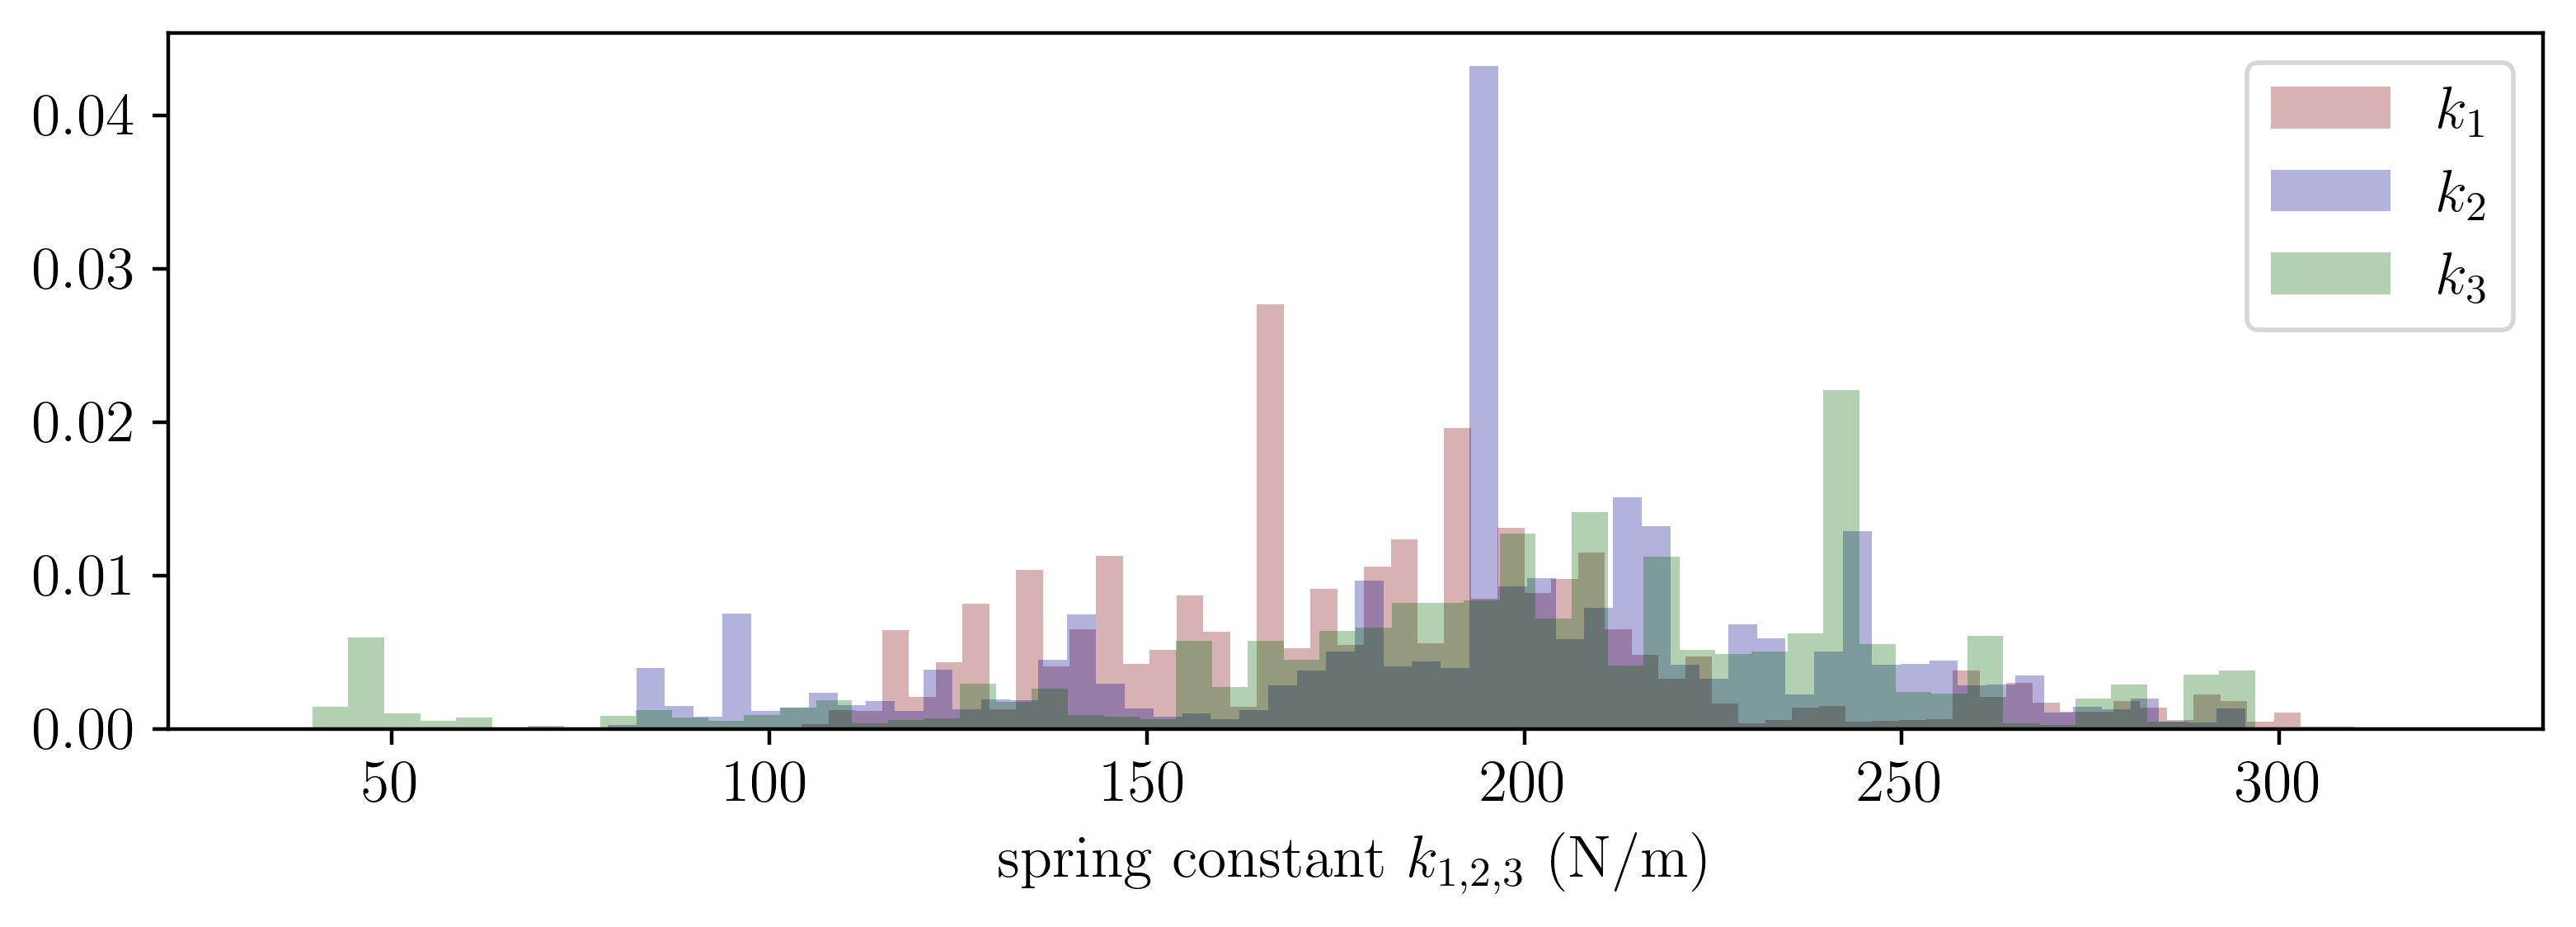

164.5723746134656 192.743985792317 239.6346682618747


In [88]:
bins = 60

fig = plt.figure(figsize=(8,3), dpi=400)

P1, k1_hist, _ = plt.hist(Paras[:,0], bins=bins, color='maroon', density=True,alpha=0.3,label="$k_1$")
P2, k2_hist, _ = plt.hist(Paras[:,1], bins=bins, color='darkblue', density=True,alpha=0.3,label="$k_2$")
P3, k3_hist, _ = plt.hist(Paras[:,2], bins=bins, color='darkgreen', density=True,alpha=0.3,label="$k_3$")

plt.xlabel("spring constant $k_{1,2,3}$ (N/m)")

plt.tight_layout()
plt.legend()
plt.show()


k1_max = k1_hist[np.where(P1 == P1.max())][0]
k2_max = k2_hist[np.where(P2 == P2.max())][0]
k3_max = k3_hist[np.where(P3 == P3.max())][0]
print(k1_max,k2_max,k3_max)

### compare

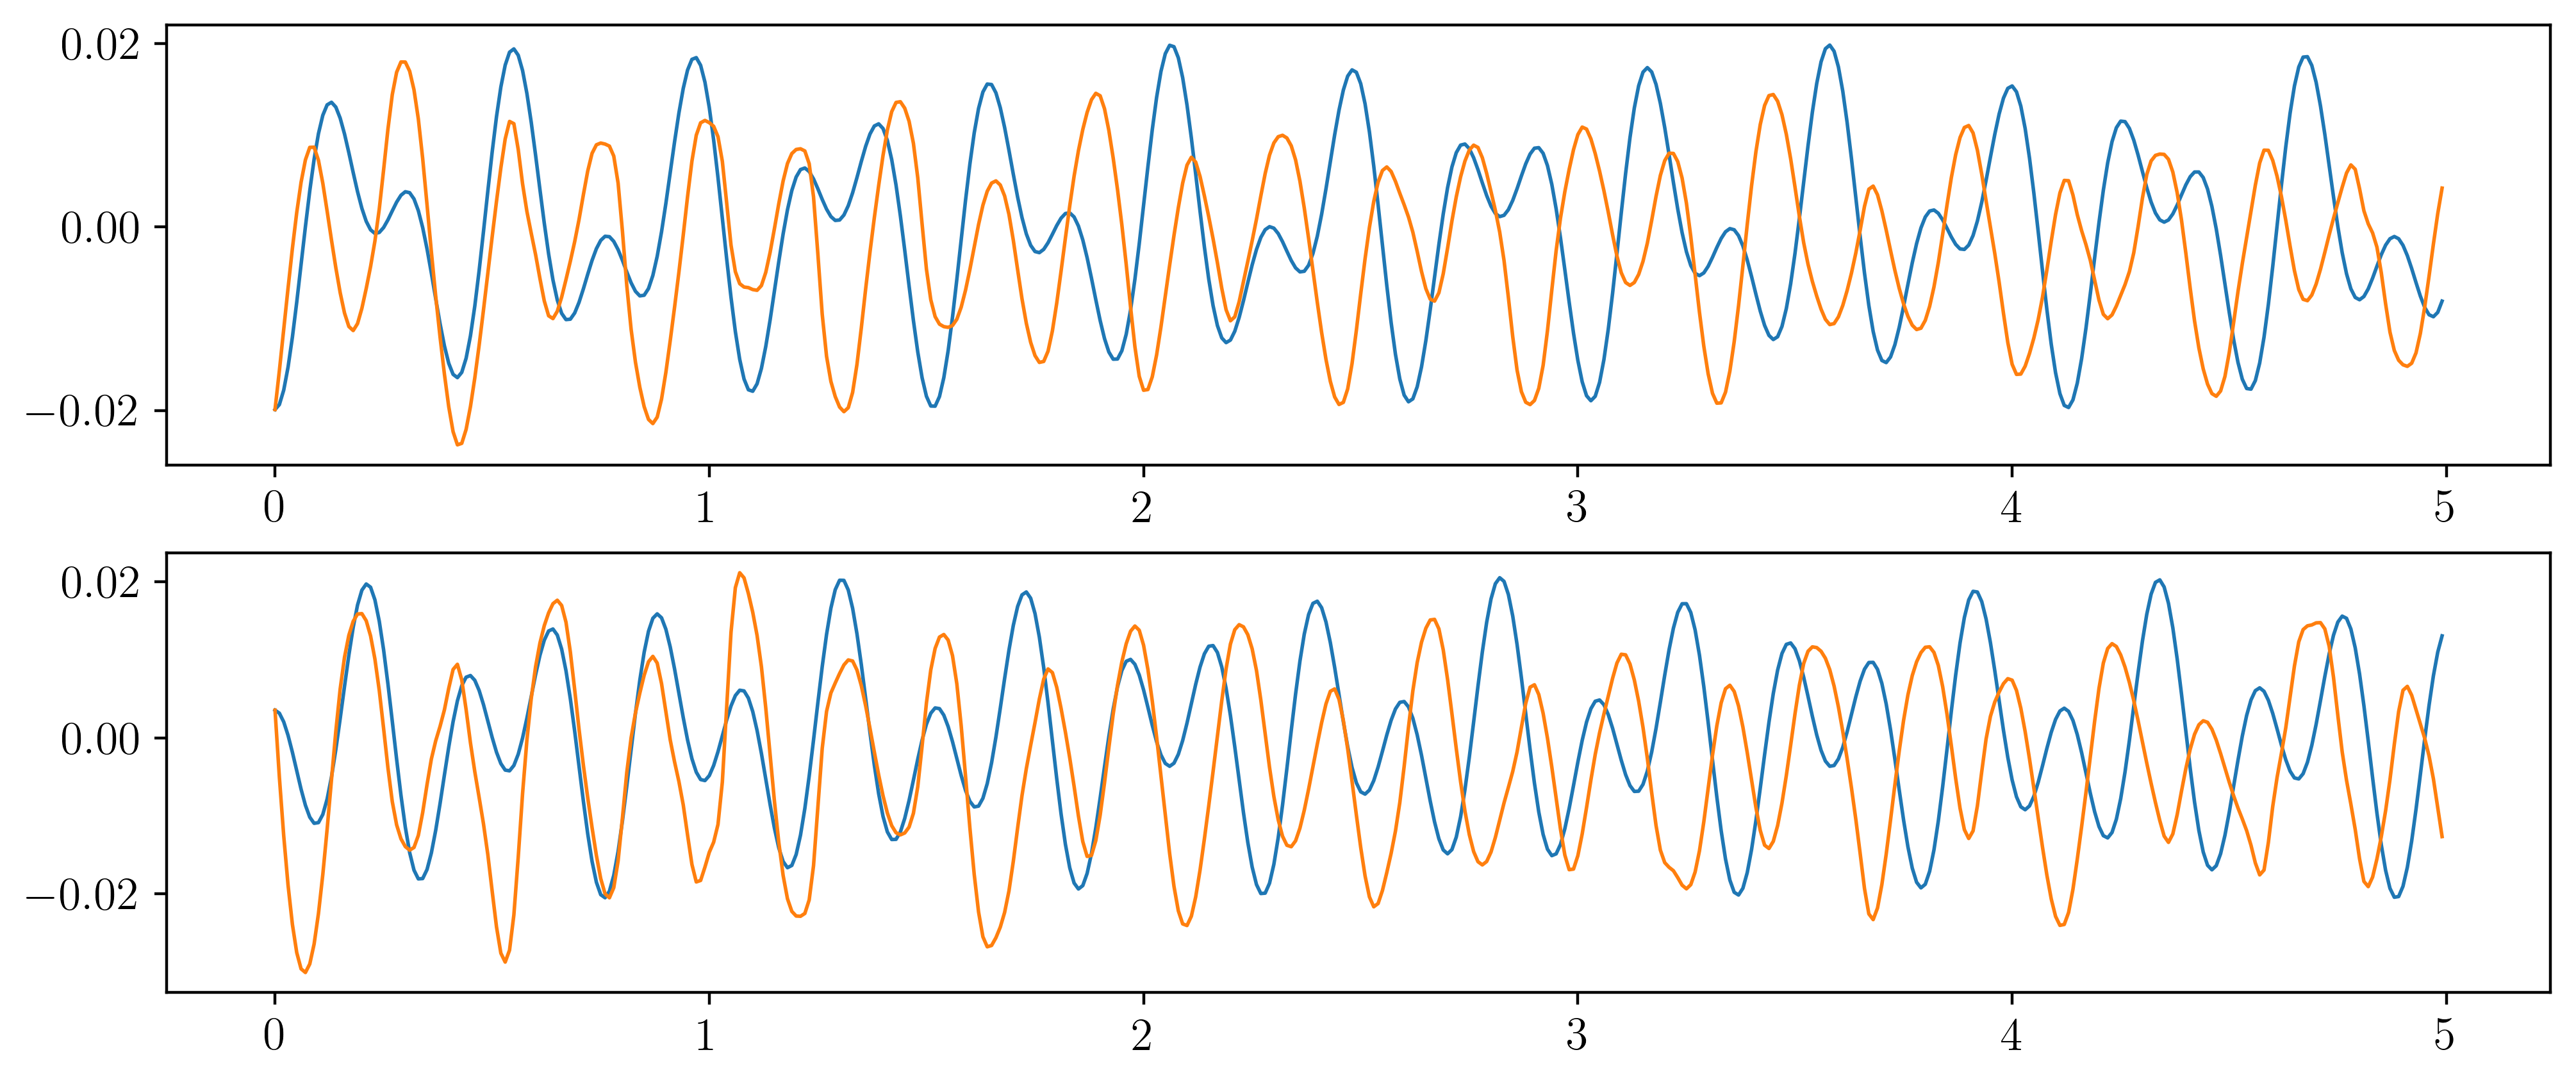

In [89]:
x1,x2 = Coupled_Oscillator(t, k1_max, k2_max, k3_max, x1_i=x1_i, x2_i=x2_i, m1=m1, m2=m2)

plt.figure(figsize=(12,5),dpi=400)
plt.subplot(2,1,1)
plt.plot(t,x1)
plt.plot(t,x1_spline(t))

plt.subplot(2,1,2)
plt.plot(t,x2)
plt.plot(t,x2_spline(t))
plt.show()